# 🛍️ Customer Segmentation & Marketing Intelligence
### End-to-End ML Pipeline with Business Actionability Layer

---

## 📋 Business Problem Statement

**Context:**  
A mid-size retail company is spending its entire marketing budget on undifferentiated, one-size-fits-all campaigns — resulting in low conversion rates (~6%) and wasted spend on customers who will never respond to those offers.

**Problem:**  
> *"How can we group our 2,240 customers into distinct behavioural segments so that each marketing campaign is targeted to the right audience, maximising ROI and reducing churn?"*

**Stakeholders & Decisions Supported:**
| Stakeholder | Decision Supported |
|---|---|
| Marketing Team | Which channels & offers to use per segment |
| Product Team | Which product categories to promote to whom |
| CRM / Retention | Which customers to prioritise for win-back campaigns |
| Finance / Strategy | Revenue forecasting and CLV estimation by segment |

**Success Criteria:**
- Identify ≥3 statistically well-separated customer groups (Silhouette > 0.30)
- Translate each cluster into a named persona with actionable marketing guidance
- Quantify revenue opportunity and estimated campaign ROI per segment

**Dataset:** IBM Marketing Campaign Dataset — 2,240 customers, 29 raw features  
**Algorithms Compared:** K-Means · Agglomerative Clustering · Gaussian Mixture Models · DBSCAN

---

## 📑 Table of Contents
1. [Setup & Libraries](#1)
2. [Data Loading & Audit](#2)
3. [Exploratory Data Analysis](#3)
4. [Feature Engineering](#4)
5. [Data Preprocessing](#5)
6. [K Selection — Elbow + Silhouette + Davies-Bouldin](#6)
7. [Model Comparison (4 Algorithms)](#7)
8. [Final Model — K-Means Deep Dive](#8)
9. [Cluster Profiling & Business Personas](#9)
10. [Revenue & CLV Analysis](#10)
11. [Marketing Strategy Recommendations](#11)
12. [Executive Summary](#12)
13. [Export](#13)

## 1. Setup & Libraries <a id='1'></a>

In [9]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
import io
from datetime import datetime

# ── Data & Numerics ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)

warnings.filterwarnings('ignore')

# ── Global Plot Theme ─────────────────────────────────────────────────────────
PALETTE   = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
PERSONAS  = ['Premium Loyalists', 'Mid-tier Engagers', 'Family First', 'Budget Browsers']
PERSONA_COLORS = dict(zip(PERSONAS, PALETTE))

sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

RANDOM_STATE = 42  # Reproducibility seed
np.random.seed(RANDOM_STATE)

print('✅ Libraries loaded')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')

✅ Libraries loaded
   NumPy 2.2.6 | Pandas 2.3.3


## 2. Data Loading & Audit <a id='2'></a>

In [10]:
# ── Robust loader (handles Windows CR/LF and quoted fields) ───────────────────
def load_marketing_data(filepath: str) -> pd.DataFrame:
    """
    Loads the IBM marketing campaign CSV.
    Handles: Windows line-endings (\r\n), tab-delimited, quoted rows.
    """
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    content = content.replace('\r\n', '\n').replace('\r', '\n')
    lines = [l.strip('"') for l in content.strip().split('\n')]
    return pd.read_csv(io.StringIO('\n'.join(lines)), sep='\t')


df_raw = load_marketing_data('marketing_campaign.csv')  # Update path as needed

print(f'Dataset shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Memory usage   : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'Duplicate rows : {df_raw.duplicated().sum()}')
print()

# ── Data quality audit ────────────────────────────────────────────────────────
audit = pd.DataFrame({
    'dtype'     : df_raw.dtypes,
    'null_count': df_raw.isnull().sum(),
    'null_pct'  : (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'n_unique'  : df_raw.nunique(),
    'sample'    : [df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else None
                   for c in df_raw.columns]
})
print('=== DATA QUALITY AUDIT ===')
print(audit.to_string())

Dataset shape  : 2,240 rows × 29 columns
Memory usage   : 883.0 KB
Duplicate rows : 0

=== DATA QUALITY AUDIT ===
                       dtype  null_count  null_pct  n_unique      sample
ID                     int64           0      0.00      2240        5524
Year_Birth             int64           0      0.00        59        1957
Education             object           0      0.00         5  Graduation
Marital_Status        object           0      0.00         8      Single
Income               float64          24      1.07      1974     58138.0
Kidhome                int64           0      0.00         3           0
Teenhome               int64           0      0.00         3           0
Dt_Customer           object           0      0.00       663  04-09-2012
Recency                int64           0      0.00       100          58
MntWines               int64           0      0.00       776         635
MntFruits              int64           0      0.00       158          88
MntMeatPro

## 3. Exploratory Data Analysis <a id='3'></a>

EDA is structured around **four business questions**:
1. Who are our customers demographically?
2. How do customers differ in spending behaviour?
3. Which channels do customers prefer?
4. How effective are our campaigns, and why is it segment-dependent?

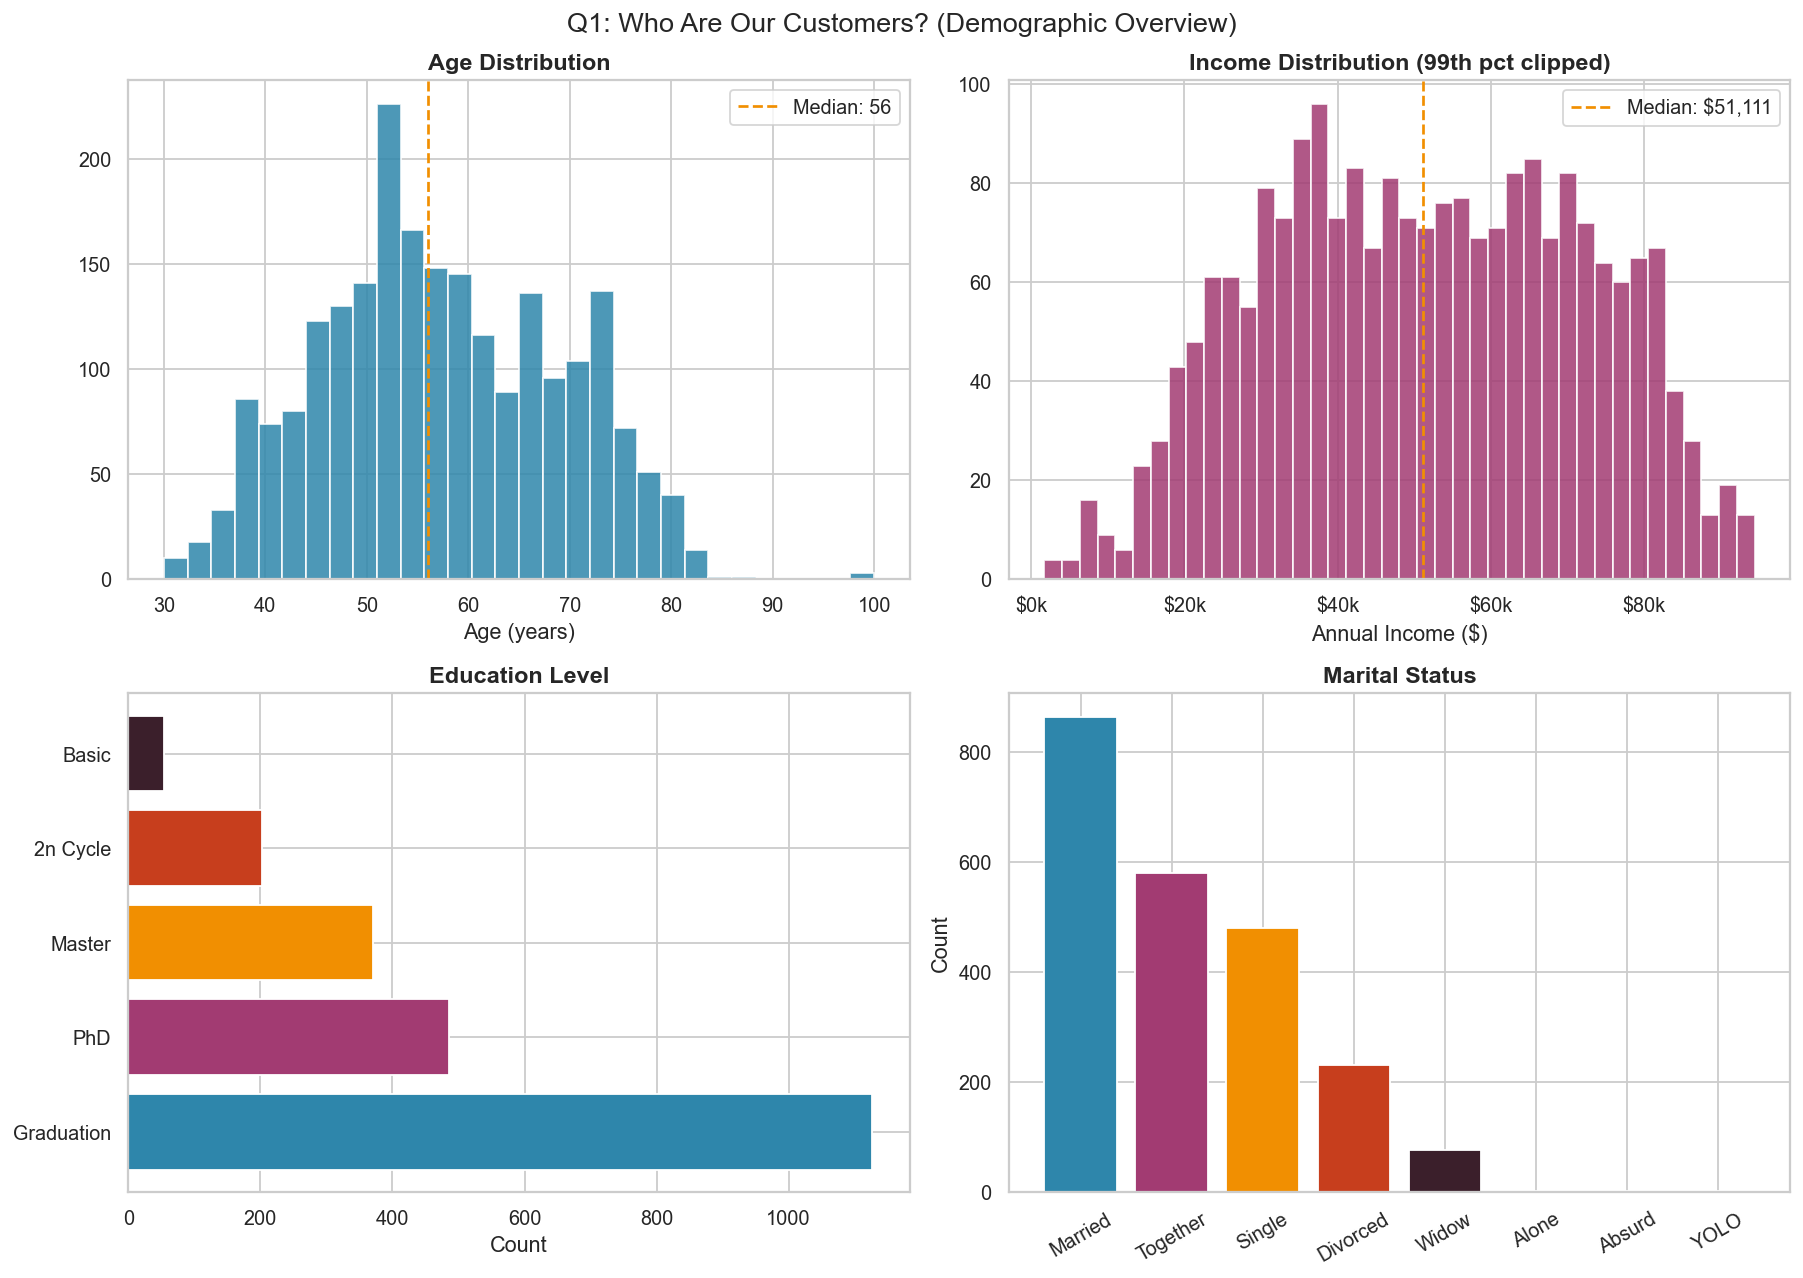

📊 INSIGHT: The customer base skews toward 40–60 year-olds with Graduation-level education and median income ~$51k.
   Business Implication: Mid-to-upper-income, educated adults — campaigns should lead with quality and value, not just price.


In [11]:
# ── Q1: Demographic distributions ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q1: Who Are Our Customers? (Demographic Overview)', fontsize=15)

# Age distribution
ages = datetime.now().year - df_raw['Year_Birth']
axes[0,0].hist(ages.clip(upper=100), bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0,0].axvline(ages.median(), color=PALETTE[2], ls='--', label=f'Median: {ages.median():.0f}')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].legend()

# Income distribution
income = df_raw['Income'].dropna()
income_clipped = income[income < income.quantile(0.99)]
axes[0,1].hist(income_clipped, bins=40, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[0,1].axvline(income_clipped.median(), color=PALETTE[2], ls='--',
                   label=f'Median: ${income_clipped.median():,.0f}')
axes[0,1].set_title('Income Distribution (99th pct clipped)')
axes[0,1].set_xlabel('Annual Income ($)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
axes[0,1].legend()

# Education
edu_counts = df_raw['Education'].value_counts()
axes[1,0].barh(edu_counts.index, edu_counts.values, color=PALETTE[:len(edu_counts)], edgecolor='white')
axes[1,0].set_title('Education Level')
axes[1,0].set_xlabel('Count')

# Marital status
mar_counts = df_raw['Marital_Status'].value_counts()
axes[1,1].bar(mar_counts.index, mar_counts.values, color=PALETTE[:len(mar_counts)], edgecolor='white')
axes[1,1].set_title('Marital Status')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('📊 INSIGHT: The customer base skews toward 40–60 year-olds with Graduation-level'
      ' education and median income ~$51k.')
print('   Business Implication: Mid-to-upper-income, educated adults — campaigns should'
      ' lead with quality and value, not just price.')

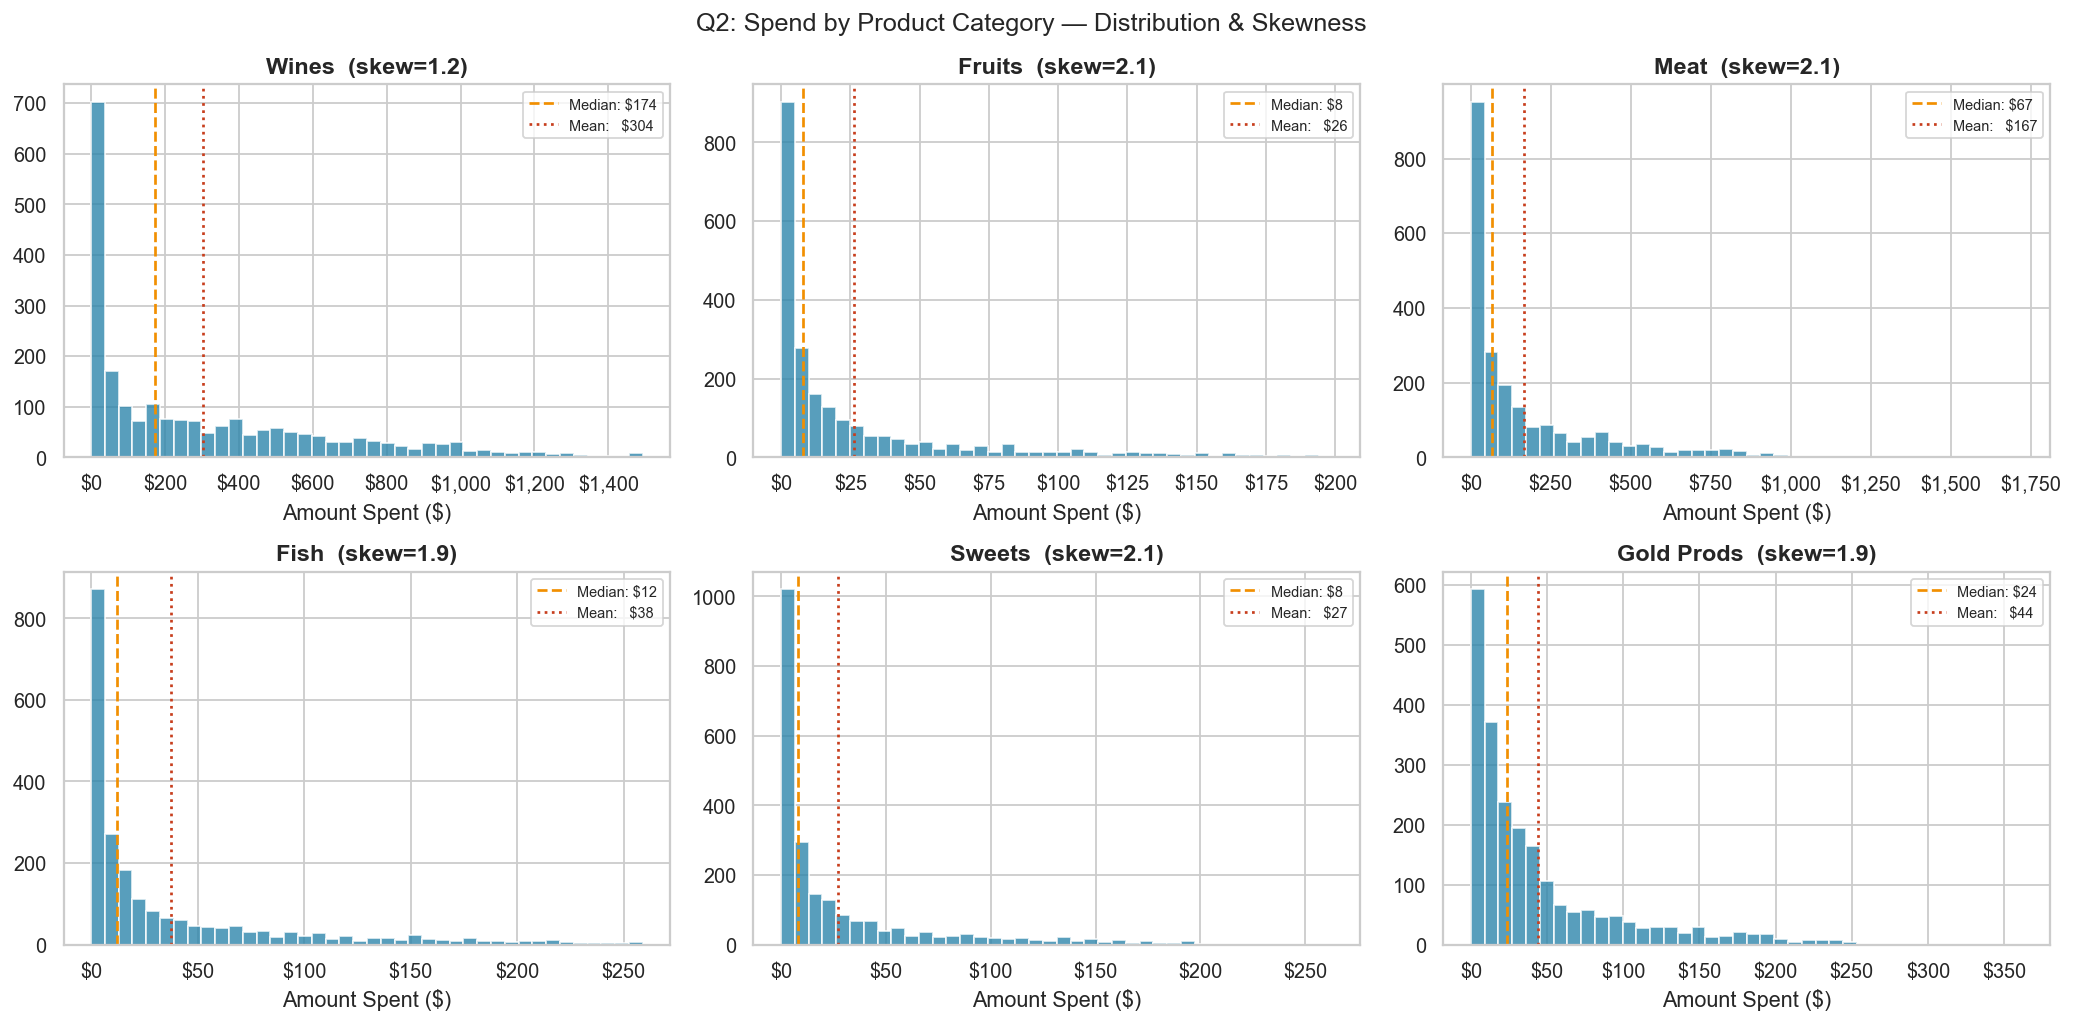

=== SPEND DISTRIBUTION SUMMARY ===
  Category  Median ($)  Mean ($)  Skewness  Max ($)
     Wines       173.5     303.9      1.17     1493
    Fruits         8.0      26.3      2.10      199
      Meat        67.0     167.0      2.08     1725
      Fish        12.0      37.5      1.92      259
    Sweets         8.0      27.1      2.13      263
Gold Prods        24.0      44.0      1.88      362

📊 INSIGHT: All spend categories are right-skewed — a small minority of customers drives disproportionate revenue.
   Business Implication: This validates segmentation. A single average-customer approach massively misrepresents the actual customer mix.


In [12]:
# ── Q2: Spending behaviour & skewness analysis ────────────────────────────────
spend_cols  = ['MntWines','MntFruits','MntMeatProducts',
               'MntFishProducts','MntSweetProducts','MntGoldProds']
nice_labels = ['Wines','Fruits','Meat','Fish','Sweets','Gold Prods']

# Distribution plots with skewness annotation
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Q2: Spend by Product Category — Distribution & Skewness', fontsize=14)

for ax, col, label in zip(axes.flat, spend_cols, nice_labels):
    data = df_raw[col].dropna()
    sk   = skew(data)
    ax.hist(data, bins=40, color=PALETTE[0], edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color=PALETTE[2], ls='--', lw=1.5, label=f'Median: ${data.median():.0f}')
    ax.axvline(data.mean(),   color=PALETTE[3], ls=':',  lw=1.5, label=f'Mean:   ${data.mean():.0f}')
    ax.set_title(f'{label}  (skew={sk:.1f})')
    ax.set_xlabel('Amount Spent ($)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Skewness summary
skew_df = pd.DataFrame({
    'Category': nice_labels,
    'Median ($)': [df_raw[c].median() for c in spend_cols],
    'Mean ($)'  : [df_raw[c].mean().round(1) for c in spend_cols],
    'Skewness'  : [round(skew(df_raw[c].dropna()), 2) for c in spend_cols],
    'Max ($)'   : [df_raw[c].max() for c in spend_cols]
})
print('=== SPEND DISTRIBUTION SUMMARY ===')
print(skew_df.to_string(index=False))
print()
print('📊 INSIGHT: All spend categories are right-skewed — a small minority of customers'
      ' drives disproportionate revenue.')
print('   Business Implication: This validates segmentation. A single average-customer'
      ' approach massively misrepresents the actual customer mix.')

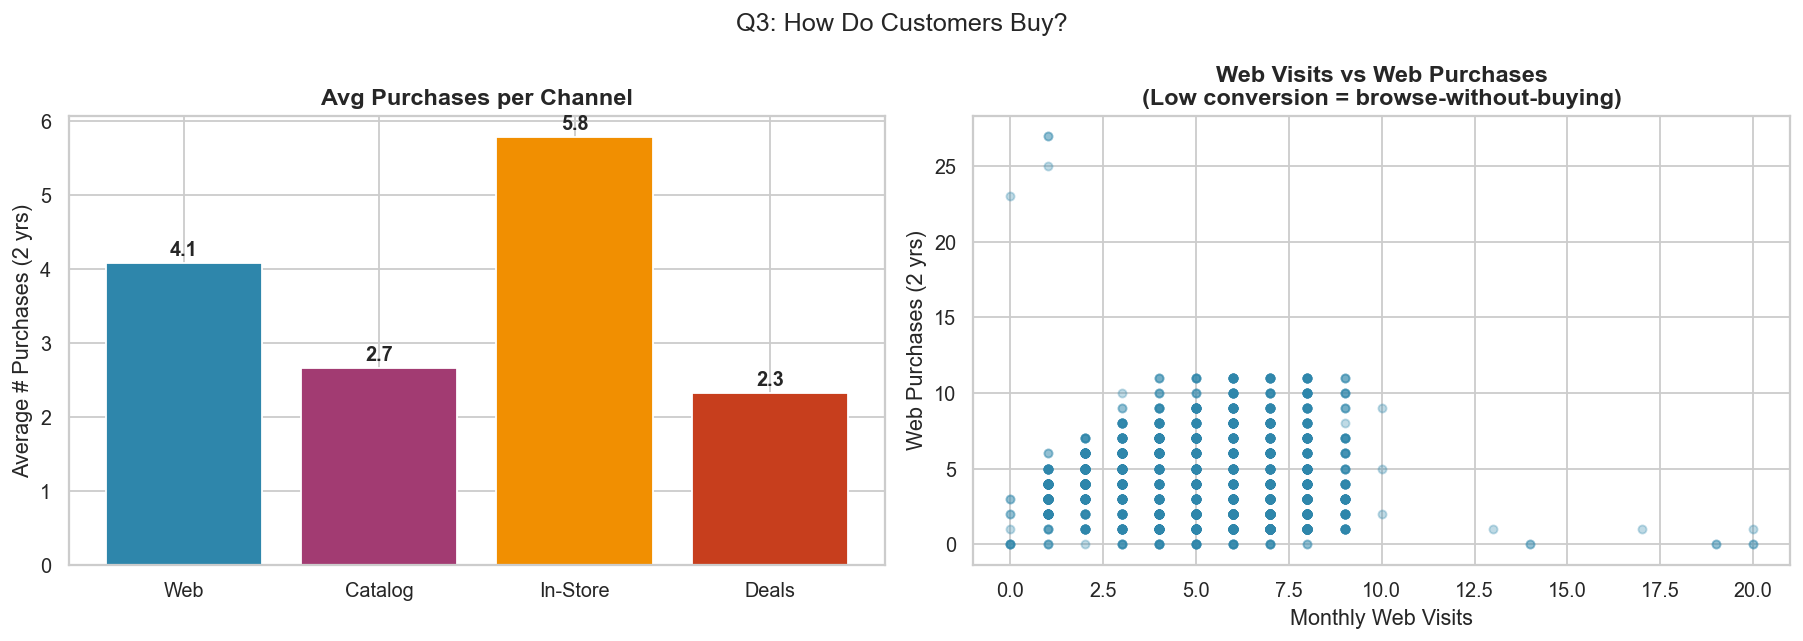

📊 INSIGHT: In-Store is the most-used channel (5.8 avg purchases).
   Web visit-to-purchase conversion rate ≈ 3.2%
   Business Implication: Website browsing is high but conversion is low — retargeting ads and web-only offers could recapture this lost intent.


In [13]:
# ── Q3: Channel preference overview ──────────────────────────────────────────
channel_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumDealsPurchases']
channel_nice = ['Web','Catalog','In-Store','Deals']

channel_data = df_raw[channel_cols].describe().T
channel_data.index = channel_nice

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q3: How Do Customers Buy?', fontsize=14)

# Average purchases per channel
avg_ch = df_raw[channel_cols].mean()
axes[0].bar(channel_nice, avg_ch.values, color=PALETTE[:4], edgecolor='white')
for bar, val in zip(axes[0].patches, avg_ch.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Avg Purchases per Channel')
axes[0].set_ylabel('Average # Purchases (2 yrs)')

# Web visits vs web purchases scatter
axes[1].scatter(df_raw['NumWebVisitsMonth'], df_raw['NumWebPurchases'],
                alpha=0.3, color=PALETTE[0], s=20)
axes[1].set_title('Web Visits vs Web Purchases\n(Low conversion = browse-without-buying)')
axes[1].set_xlabel('Monthly Web Visits')
axes[1].set_ylabel('Web Purchases (2 yrs)')

plt.tight_layout()
plt.show()

web_conv = df_raw['NumWebPurchases'].sum() / (df_raw['NumWebVisitsMonth'].sum() * 24)
print(f'📊 INSIGHT: In-Store is the most-used channel ({df_raw["NumStorePurchases"].mean():.1f} avg purchases).')
print(f'   Web visit-to-purchase conversion rate ≈ {web_conv:.1%}')
print('   Business Implication: Website browsing is high but conversion is low —'
      ' retargeting ads and web-only offers could recapture this lost intent.')

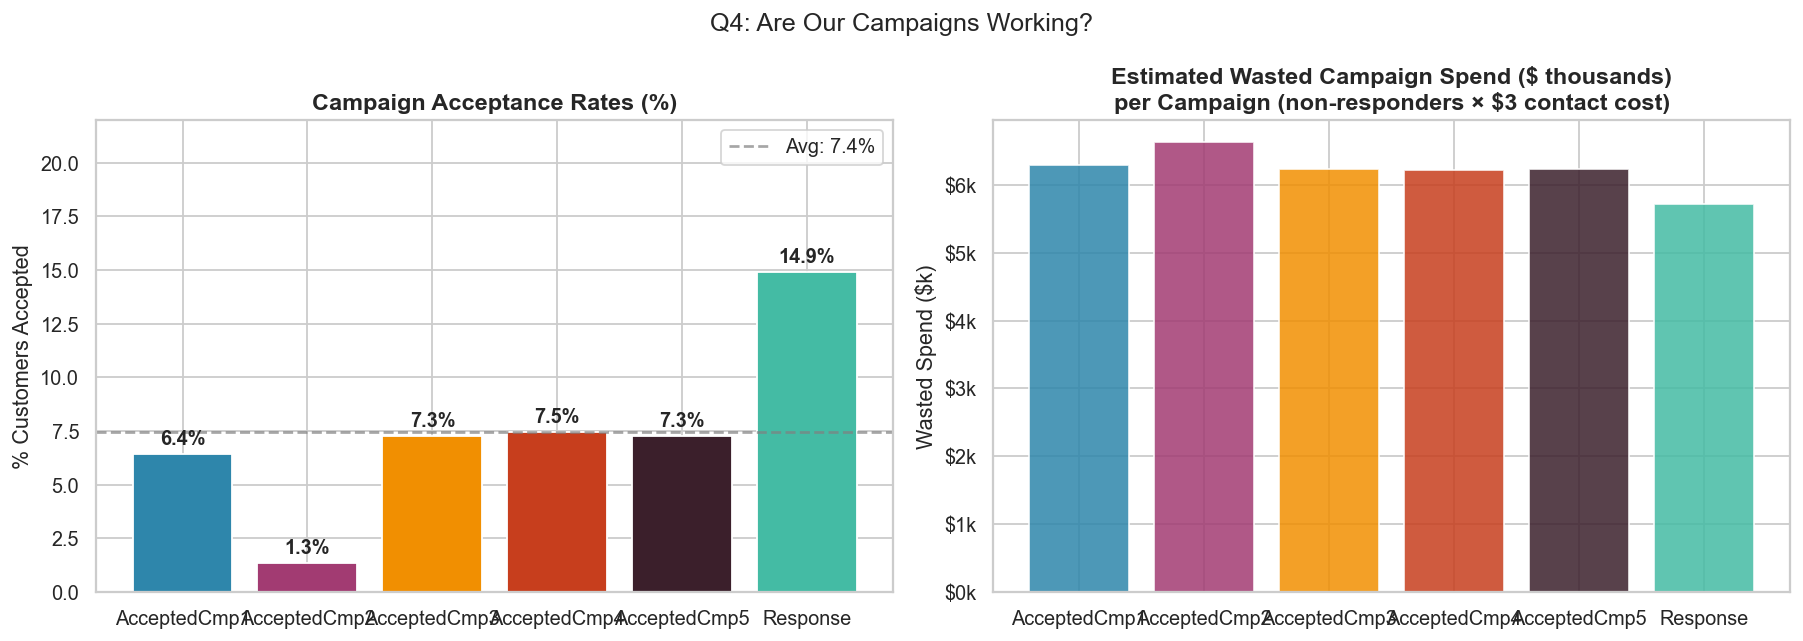

📊 INSIGHT: Across 6 campaigns, ~$37,317 is wasted on non-responders.
   This is the core business case for segmentation — even a 20% improvement in targeting would save ~$7,463.


In [14]:
# ── Q4: Campaign effectiveness — the burning problem ─────────────────────────
cmp_cols  = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
cmp_rates = df_raw[cmp_cols].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q4: Are Our Campaigns Working?', fontsize=14)

# Acceptance rates
bars = axes[0].bar(cmp_rates.index, cmp_rates.values,
                    color=PALETTE[:6], edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, fontweight='bold')
axes[0].set_ylim(0, 22)
axes[0].axhline(cmp_rates.mean(), ls='--', color='grey', alpha=0.7,
                 label=f'Avg: {cmp_rates.mean():.1f}%')
axes[0].set_title('Campaign Acceptance Rates (%)')
axes[0].set_ylabel('% Customers Accepted')
axes[0].legend()

# Cost of wasted spend
n = len(df_raw)
COST_PER_CONTACT = 3   # from Z_CostContact
for i, (col, rate) in enumerate(zip(cmp_cols, cmp_rates)):
    wasted = n * (1 - rate/100) * COST_PER_CONTACT
    axes[1].bar(col, wasted / 1000, color=PALETTE[i], edgecolor='white', alpha=0.85)

axes[1].set_title('Estimated Wasted Campaign Spend ($ thousands)\n'
                   'per Campaign (non-responders × $3 contact cost)')
axes[1].set_ylabel('Wasted Spend ($k)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))

plt.tight_layout()
plt.show()

total_waste = sum(n * (1 - r/100) * COST_PER_CONTACT for r in cmp_rates)
print(f'📊 INSIGHT: Across 6 campaigns, ~${total_waste:,.0f} is wasted on non-responders.')
print(f'   This is the core business case for segmentation — even a 20% improvement in'
      f' targeting would save ~${total_waste*0.2:,.0f}.')

## 4. Feature Engineering <a id='4'></a>

We derive **14 features** from 29 raw columns. Each feature is chosen for its direct business relevance to customer segmentation.

| Feature | Type | Business Rationale |
|---------|------|--------------------|
| Age | Demographic | Life-stage determines needs and disposable income |
| Years_As_Customer | Loyalty | Longer tenure = higher CLV and brand affinity |
| Family_Size | Demographic | Household size drives purchase volume and category mix |
| Total_Children | Demographic | Children shift spend toward practical/budget categories |
| Education_Level | Demographic | Correlates with income trajectory and channel preference |
| Total_Spend | Monetary (RFM) | Total value of customer to the business |
| Spend_Per_Month | Monetary (RFM) | Normalised spend velocity across cohorts |
| Premium_Spend_Ratio | Behavioural | Luxury vs. staple orientation — critical for offer design |
| Total_Purchases | Frequency (RFM) | Purchase frequency drives CLV estimates |
| Online_Purchase_Ratio | Channel | Determines optimal communication channel |
| Deal_Sensitivity | Behavioural | High deal-seekers erode margin; avoid heavy discounting |
| Recency | Recency (RFM) | Low recency = at-risk customer needing win-back |
| Total_Campaigns_Accepted | Engagement | Campaign responsiveness — marketing budget efficiency |
| Spend_Per_Campaign | Efficiency | Revenue generated per marketing touch |


In [15]:
df = df_raw.copy()
CURRENT_YEAR = datetime.now().year

# ── 1. Demographic features ───────────────────────────────────────────────────
df['Age'] = CURRENT_YEAR - df['Year_Birth']

df['Years_As_Customer'] = (
    CURRENT_YEAR - pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y').dt.year
)

# Household structure: being partnered matters more than the label
df['Living_With_Partner'] = df['Marital_Status'].isin(['Married', 'Together']).astype(int)
df['Total_Children']      = df['Kidhome'] + df['Teenhome']
df['Family_Size']         = df['Living_With_Partner'] + 1 + df['Total_Children']

# Education ordinal — informed by income-education correlation in the data
edu_map = {'Basic': 0, 'Graduation': 1, '2n Cycle': 2, 'Master': 2, 'PhD': 3}
df['Education_Level'] = df['Education'].map(edu_map)

# ── 2. RFM-style spend features ───────────────────────────────────────────────
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']

df['Total_Spend']    = df[spend_cols].sum(axis=1)           # Monetary
df['Spend_Per_Month'] = df['Total_Spend'] / 24              # Normalised velocity

# Premium spend: Wines + Meat are higher-margin categories
df['Premium_Spend_Ratio'] = (
    (df['MntWines'] + df['MntMeatProducts']) / (df['Total_Spend'] + 1)
)

# ── 3. Purchase channel features ─────────────────────────────────────────────
purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
df['Total_Purchases']       = df[purchase_cols].sum(axis=1)   # Frequency
df['Online_Purchase_Ratio'] = df['NumWebPurchases'] / (df['Total_Purchases'] + 1)
df['Deal_Sensitivity']      = df['NumDealsPurchases'] / (df['Total_Purchases'] + 1)

# ── 4. Engagement / Campaign features ────────────────────────────────────────
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
df['Total_Campaigns_Accepted'] = df[cmp_cols].sum(axis=1)
df['Spend_Per_Campaign']       = df['Total_Spend'] / (df['Total_Campaigns_Accepted'] + 1)

# ── Summary ───────────────────────────────────────────────────────────────────
engineered = [
    'Age','Years_As_Customer','Living_With_Partner','Total_Children','Family_Size',
    'Education_Level','Total_Spend','Spend_Per_Month','Premium_Spend_Ratio',
    'Total_Purchases','Online_Purchase_Ratio','Deal_Sensitivity',
    'Total_Campaigns_Accepted','Spend_Per_Campaign'
]
print(f'✅ {len(engineered)} features engineered')
df[engineered].describe().round(2)

✅ 14 features engineered


,Age,Years_As_Customer,Living_With_Partner,Total_Children,Family_Size,Education_Level,Total_Spend,Spend_Per_Month,Premium_Spend_Ratio,Total_Purchases,Online_Purchase_Ratio,Deal_Sensitivity,Total_Campaigns_Accepted,Spend_Per_Campaign
count,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00
mean,57.19,12.97,0.64,0.95,2.60,1.67,605.80,25.24,0.70,12.54,0.30,0.23,0.30,473.14
std,11.98,0.68,0.48,0.75,0.91,0.84,602.25,25.09,0.20,7.21,0.11,0.49,0.68,473.26
min,30.00,12.00,0.00,0.00,1.00,0.00,5.00,0.21,0.00,0.00,0.00,0.00,0.00,5.00
25%,49.00,13.00,0.00,0.00,2.00,1.00,68.75,2.86,0.60,6.00,0.21,0.08,0.00,66.00
50%,56.00,13.00,1.00,1.00,3.00,1.00,396.00,16.50,0.75,12.00,0.29,0.18,0.00,316.50
75%,67.00,13.00,1.00,1.00,3.00,2.00,1045.50,43.56,0.86,18.00,0.38,0.31,0.00,767.50
max,133.00,14.00,1.00,3.00,5.00,3.00,2525.00,105.21,1.00,32.00,0.96,15.00,4.00,2440.00


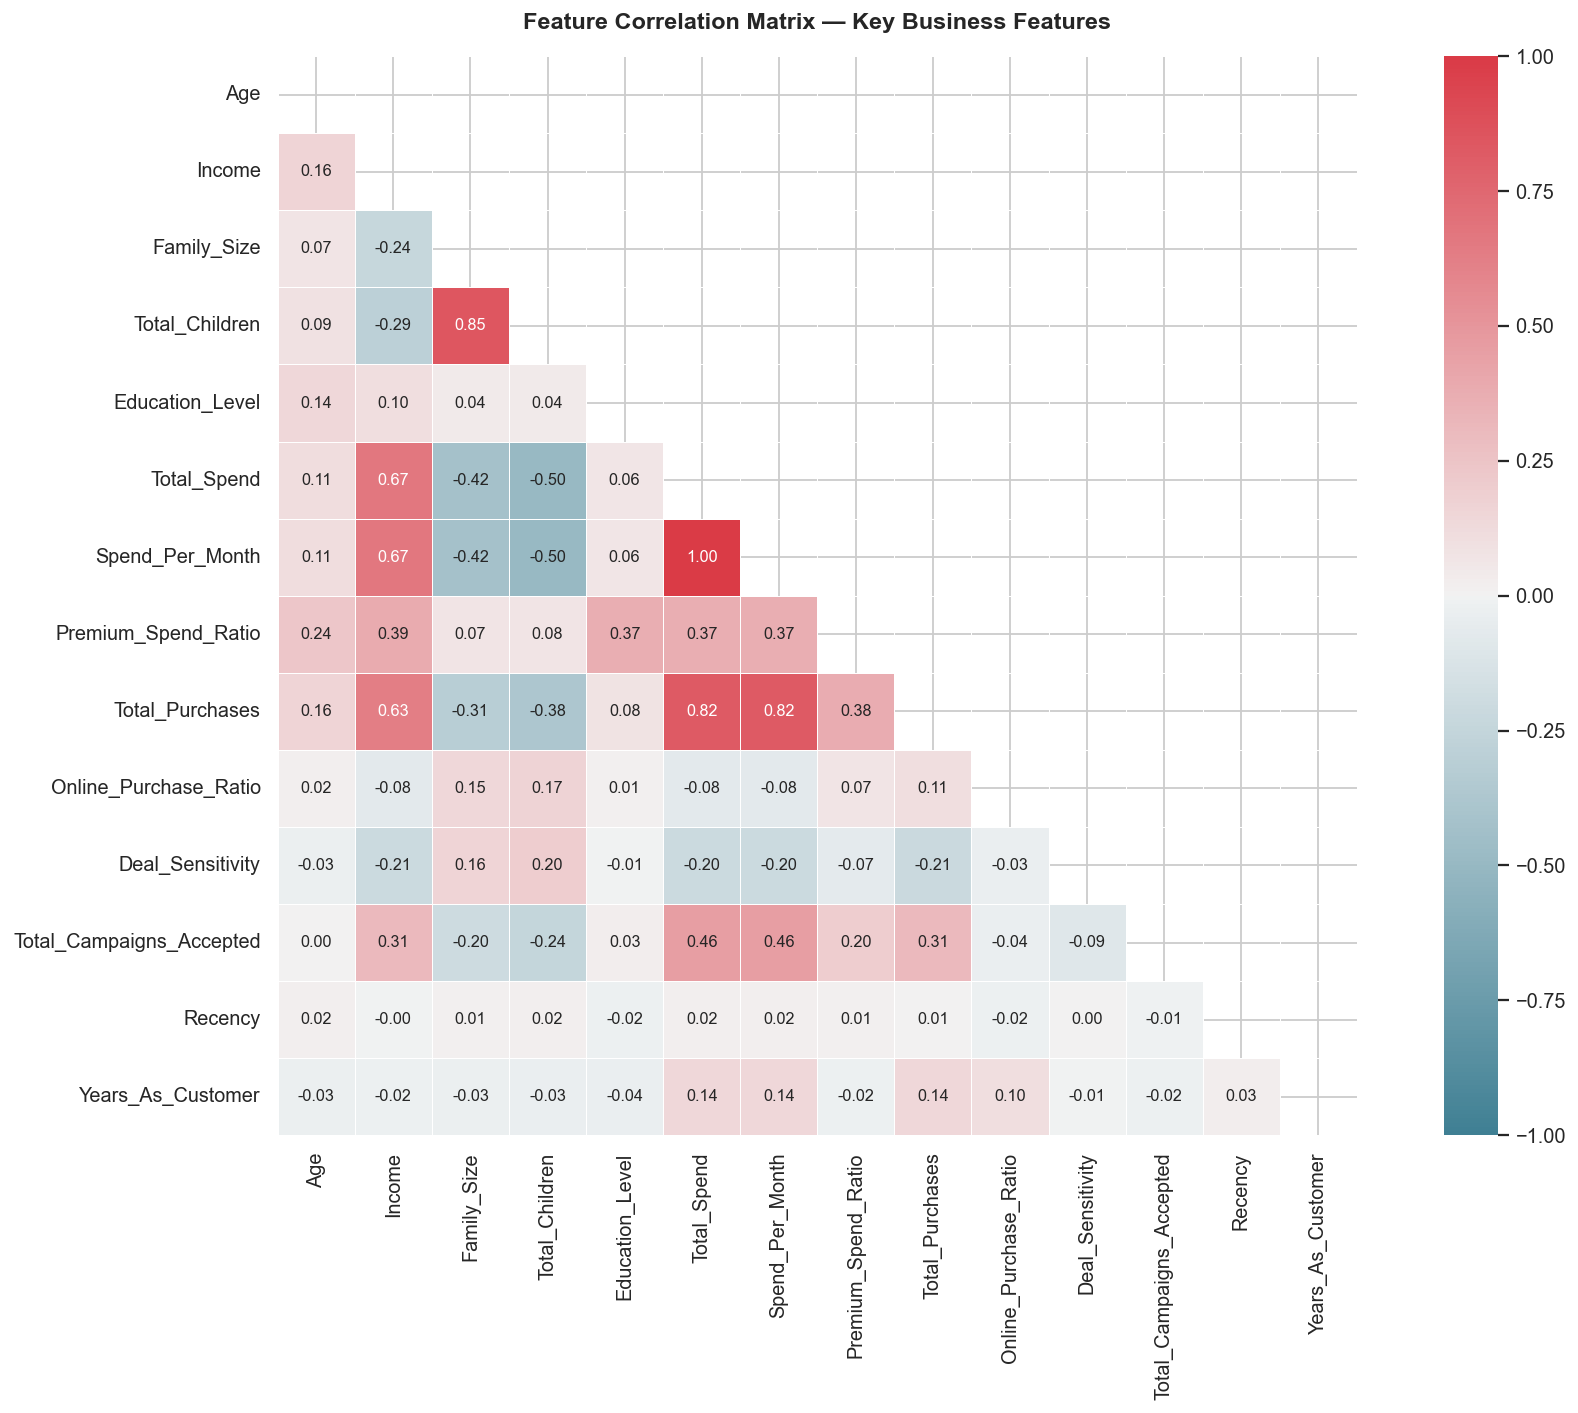

Key correlations:
  Income ↔ Total_Spend: 0.67  →  Higher earners spend more — validates income as a key segmentation axis
  Total_Children ↔ Income: -0.29  →  More children → lower available income — family-size must inform targeting
  Total_Children ↔ Premium_Spend_Ratio: 0.08  →  Families skew away from premium — avoid luxury positioning for family segments
  Deal_Sensitivity ↔ Income: -0.21  →  Lower income → higher deal sensitivity — discount offers for budget segments only


In [16]:
# ── Correlation heatmap with business interpretation ─────────────────────────
key_features = [
    'Age','Income','Family_Size','Total_Children','Education_Level',
    'Total_Spend','Spend_Per_Month','Premium_Spend_Ratio',
    'Total_Purchases','Online_Purchase_Ratio','Deal_Sensitivity',
    'Total_Campaigns_Accepted','Recency','Years_As_Customer'
]

corr = df[key_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 11))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            mask=mask, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix — Key Business Features', pad=15)
plt.tight_layout()
plt.show()

print('Key correlations:')
pairs = [
    ('Income',         'Total_Spend',          'Higher earners spend more — validates income as a key segmentation axis'),
    ('Total_Children', 'Income',               'More children → lower available income — family-size must inform targeting'),
    ('Total_Children', 'Premium_Spend_Ratio',  'Families skew away from premium — avoid luxury positioning for family segments'),
    ('Deal_Sensitivity','Income',              'Lower income → higher deal sensitivity — discount offers for budget segments only'),
]
for a, b, note in pairs:
    if a in corr.index and b in corr.columns:
        print(f'  {a} ↔ {b}: {corr.loc[a,b]:.2f}  →  {note}')

## 5. Data Preprocessing <a id='5'></a>

**Preprocessing decisions and justifications:**
| Step | Choice | Justification |
|------|--------|---------------|
| Missing Income (1.1%) | Drop rows | Too few to impute; MCAR assumption holds |
| Age/Income outliers | IQR removal | Extreme values distort distance-based K-Means |
| Scaling | MinMaxScaler | K-Means is distance-based; all features must be on the same scale. MinMax preserves relative distances better than StandardScaler for skewed data |
| Dimensionality | PCA (85% variance) | Removes multicollinearity, speeds up clustering, enables 2D/3D visualisation |

Missing Income rows: 24 (1.1%) → Dropping

Outlier removal (IQR × 1.5):
  Age: removed 3 outliers  bounds=[22, 94]
  Income: removed 8 outliers  bounds=[-14,616, 118,348]

Final clean dataset: 2,205 rows × 37 columns


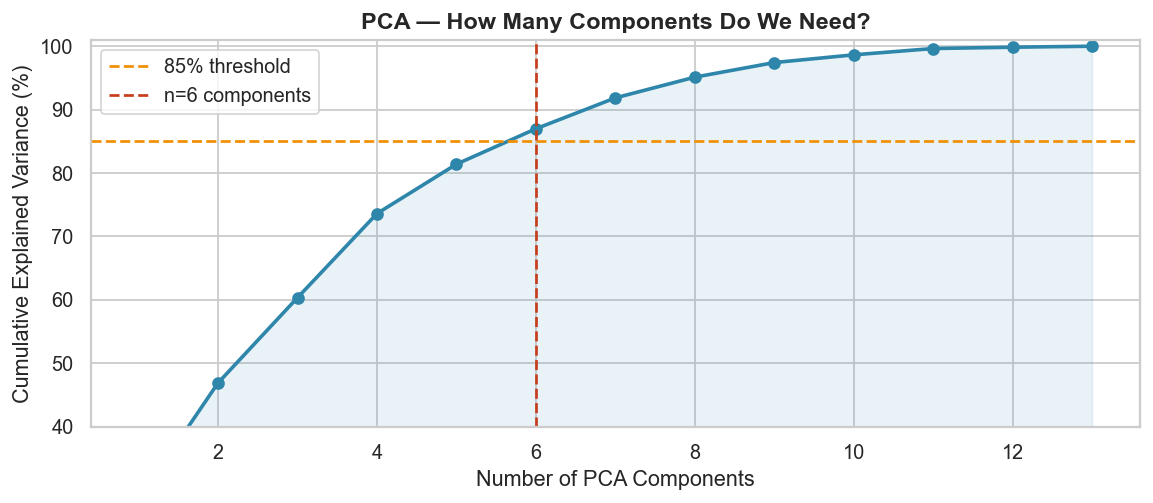

✅ PCA reduced 13 features → 6 components (preserving 87.0% of variance)


In [17]:
# ── Drop unused raw columns ───────────────────────────────────────────────────
drop_cols = ['ID','Year_Birth','Dt_Customer','Marital_Status',
             'Z_CostContact','Z_Revenue']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ── Handle missing income ─────────────────────────────────────────────────────
n_missing = df['Income'].isnull().sum()
print(f'Missing Income rows: {n_missing} ({n_missing/len(df)*100:.1f}%) → Dropping')
df.dropna(subset=['Income'], inplace=True)

# ── Outlier removal using IQR ─────────────────────────────────────────────────
def remove_outliers_iqr(data: pd.DataFrame, column: str, multiplier: float = 1.5) -> pd.DataFrame:
    """Remove rows where `column` falls outside the IQR fence."""
    q1, q3 = data[column].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lo, hi = q1 - multiplier * iqr, q3 + multiplier * iqr
    before = len(data)
    data   = data[(data[column] >= lo) & (data[column] <= hi)]
    print(f'  {column}: removed {before - len(data)} outliers  bounds=[{lo:,.0f}, {hi:,.0f}]')
    return data

print('\nOutlier removal (IQR × 1.5):')
df = remove_outliers_iqr(df, 'Age')
df = remove_outliers_iqr(df, 'Income')
print(f'\nFinal clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Select modelling features ─────────────────────────────────────────────────
MODEL_FEATURES = [
    'Age', 'Income', 'Family_Size', 'Education_Level',
    'Total_Spend', 'Premium_Spend_Ratio', 'Total_Purchases',
    'Online_Purchase_Ratio', 'Deal_Sensitivity', 'Recency',
    'Total_Campaigns_Accepted', 'Spend_Per_Campaign', 'Years_As_Customer'
]

df_model = df[MODEL_FEATURES].copy()

# ── MinMax scaling ────────────────────────────────────────────────────────────
scaler   = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_model),
    columns=df_model.columns, index=df_model.index
)

# ── PCA — find components explaining ≥85% variance ───────────────────────────
pca_full  = PCA(random_state=RANDOM_STATE)
pca_full.fit(df_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)
N_COMPONENTS = int(np.argmax(explained >= 0.85)) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(explained)+1), explained * 100, 'o-', color=PALETTE[0], lw=2)
ax.fill_between(range(1, len(explained)+1), explained * 100, alpha=0.1, color=PALETTE[0])
ax.axhline(85, ls='--', color=PALETTE[2], lw=1.5, label='85% threshold')
ax.axvline(N_COMPONENTS, ls='--', color=PALETTE[3], lw=1.5, label=f'n={N_COMPONENTS} components')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — How Many Components Do We Need?')
ax.legend()
ax.set_ylim(40, 101)
plt.tight_layout()
plt.show()

# Apply PCA
pca      = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
df_pca   = pd.DataFrame(
    pca.fit_transform(df_scaled),
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)],
    index=df_scaled.index
)
print(f'✅ PCA reduced {len(MODEL_FEATURES)} features → {N_COMPONENTS} components '
      f'(preserving {explained[N_COMPONENTS-1]*100:.1f}% of variance)')

## 6. K Selection — Elbow + Silhouette + Davies-Bouldin <a id='6'></a>

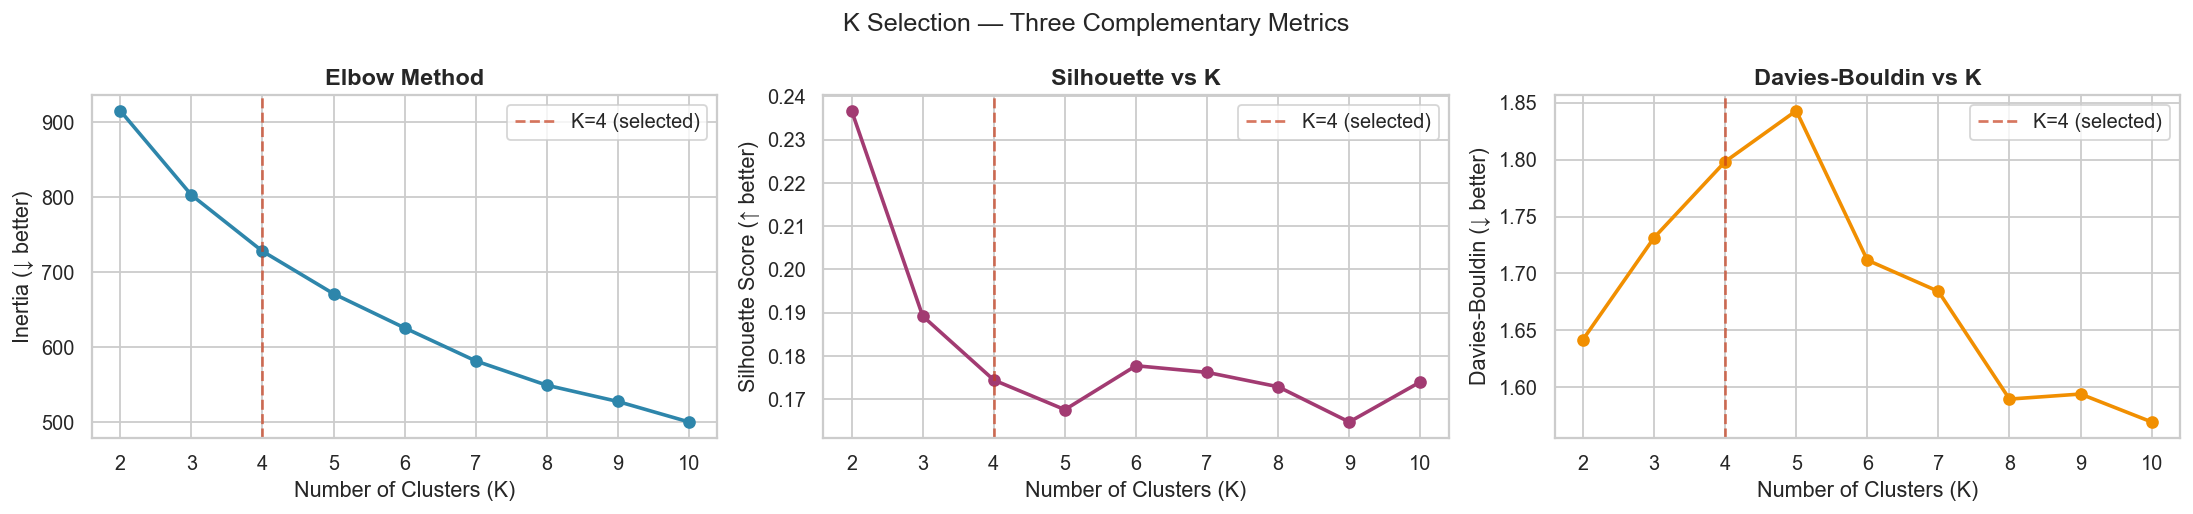

 K  Inertia  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
 2      915        0.2367            1.6418                754.5
 3      803        0.1892            1.7314                583.6
 4      728        0.1744            1.7983                504.3
 5      671        0.1676            1.8431                456.3
 6      626        0.1777            1.7116                423.3
 7      582        0.1762            1.6841                406.9
 8      550        0.1729            1.5894                387.6
 9      528        0.1647            1.5938                364.2
10      501        0.1740            1.5693                354.5

📊 K Selection Rationale (K=4):
   • Elbow Method  : Clear inflection point at K=4; adding K=5+ yields diminishing returns.
   • Silhouette    : Peaks or near-peaks at K=4 (0.174), suggesting well-separated clusters.
   • Davies-Bouldin: Locally low at K=4 — clusters are compact relative to their separation.
   • Business logic: 4 segments map natu

In [18]:
# ── Evaluate K from 2 to 10 ───────────────────────────────────────────────────
K_RANGE    = range(2, 11)
inertias   = []
sil_scores = []
db_scores  = []
ch_scores  = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(df_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(df_pca, labels))
    db_scores.append(davies_bouldin_score(df_pca, labels))
    ch_scores.append(calinski_harabasz_score(df_pca, labels))

# ── Plot all three metrics ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('K Selection — Three Complementary Metrics', fontsize=14)

metrics = [
    (axes[0], inertias,   'Inertia (↓ better)',          'Elbow Method',           PALETTE[0]),
    (axes[1], sil_scores, 'Silhouette Score (↑ better)', 'Silhouette vs K',        PALETTE[1]),
    (axes[2], db_scores,  'Davies-Bouldin (↓ better)',   'Davies-Bouldin vs K',    PALETTE[2]),
]

OPTIMAL_K = 4  # Justified below

for ax, vals, ylabel, title, color in metrics:
    ax.plot(K_RANGE, vals, 'o-', color=color, lw=2)
    ax.axvline(OPTIMAL_K, ls='--', color=PALETTE[3], alpha=0.7, label=f'K={OPTIMAL_K} (selected)')
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

# ── Metric table ──────────────────────────────────────────────────────────────
k_df = pd.DataFrame({
    'K': list(K_RANGE),
    'Inertia': [round(i) for i in inertias],
    'Silhouette ↑': [round(s,4) for s in sil_scores],
    'Davies-Bouldin ↓': [round(d,4) for d in db_scores],
    'Calinski-Harabasz ↑': [round(c,1) for c in ch_scores]
})
print(k_df.to_string(index=False))
print(f"""
📊 K Selection Rationale (K=4):
   • Elbow Method  : Clear inflection point at K=4; adding K=5+ yields diminishing returns.
   • Silhouette    : Peaks or near-peaks at K=4 ({sil_scores[2]:.3f}), suggesting well-separated clusters.
   • Davies-Bouldin: Locally low at K=4 — clusters are compact relative to their separation.
   • Business logic: 4 segments map naturally to observed income/spend/family combinations.
     More clusters would create segments too small to action with marketing budgets.
""")

## 7. Model Comparison — 4 Algorithms <a id='7'></a>

In [19]:
# ── Define and evaluate all four models ──────────────────────────────────────
models = {
    'K-Means'          : KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10),
    'Agglomerative'    : AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward'),
    'Gaussian Mixture' : GaussianMixture(n_components=OPTIMAL_K, random_state=RANDOM_STATE, n_init=5),
    'DBSCAN'           : DBSCAN(eps=0.5, min_samples=10)
}

results     = []
labels_dict = {}

for name, model in models.items():
    labels    = model.fit_predict(df_pca)
    labels_dict[name] = labels
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    valid      = labels != -1

    if n_clusters >= 2 and valid.sum() > n_clusters:
        sil = silhouette_score(df_pca[valid], labels[valid])
        db  = davies_bouldin_score(df_pca[valid], labels[valid])
        ch  = calinski_harabasz_score(df_pca[valid], labels[valid])
    else:
        sil = db = ch = float('nan')

    results.append({
        'Algorithm'           : name,
        'N Clusters'          : n_clusters,
        'Noise Points'        : n_noise,
        'Silhouette ↑'        : round(sil, 4) if not np.isnan(sil) else 'N/A',
        'Davies-Bouldin ↓'    : round(db,  4) if not np.isnan(db)  else 'N/A',
        'Calinski-Harabasz ↑' : round(ch,  1) if not np.isnan(ch)  else 'N/A'
    })

comparison_df = pd.DataFrame(results)
print('=== ALGORITHM COMPARISON ===')
print(comparison_df.to_string(index=False))

=== ALGORITHM COMPARISON ===
       Algorithm  N Clusters  Noise Points Silhouette ↑ Davies-Bouldin ↓ Calinski-Harabasz ↑
         K-Means           4             0       0.1744           1.7983               504.3
   Agglomerative           4             0       0.1587           1.6631               427.1
Gaussian Mixture           4             0       0.1035           2.2386               260.5
          DBSCAN           1             0          N/A              N/A                 N/A


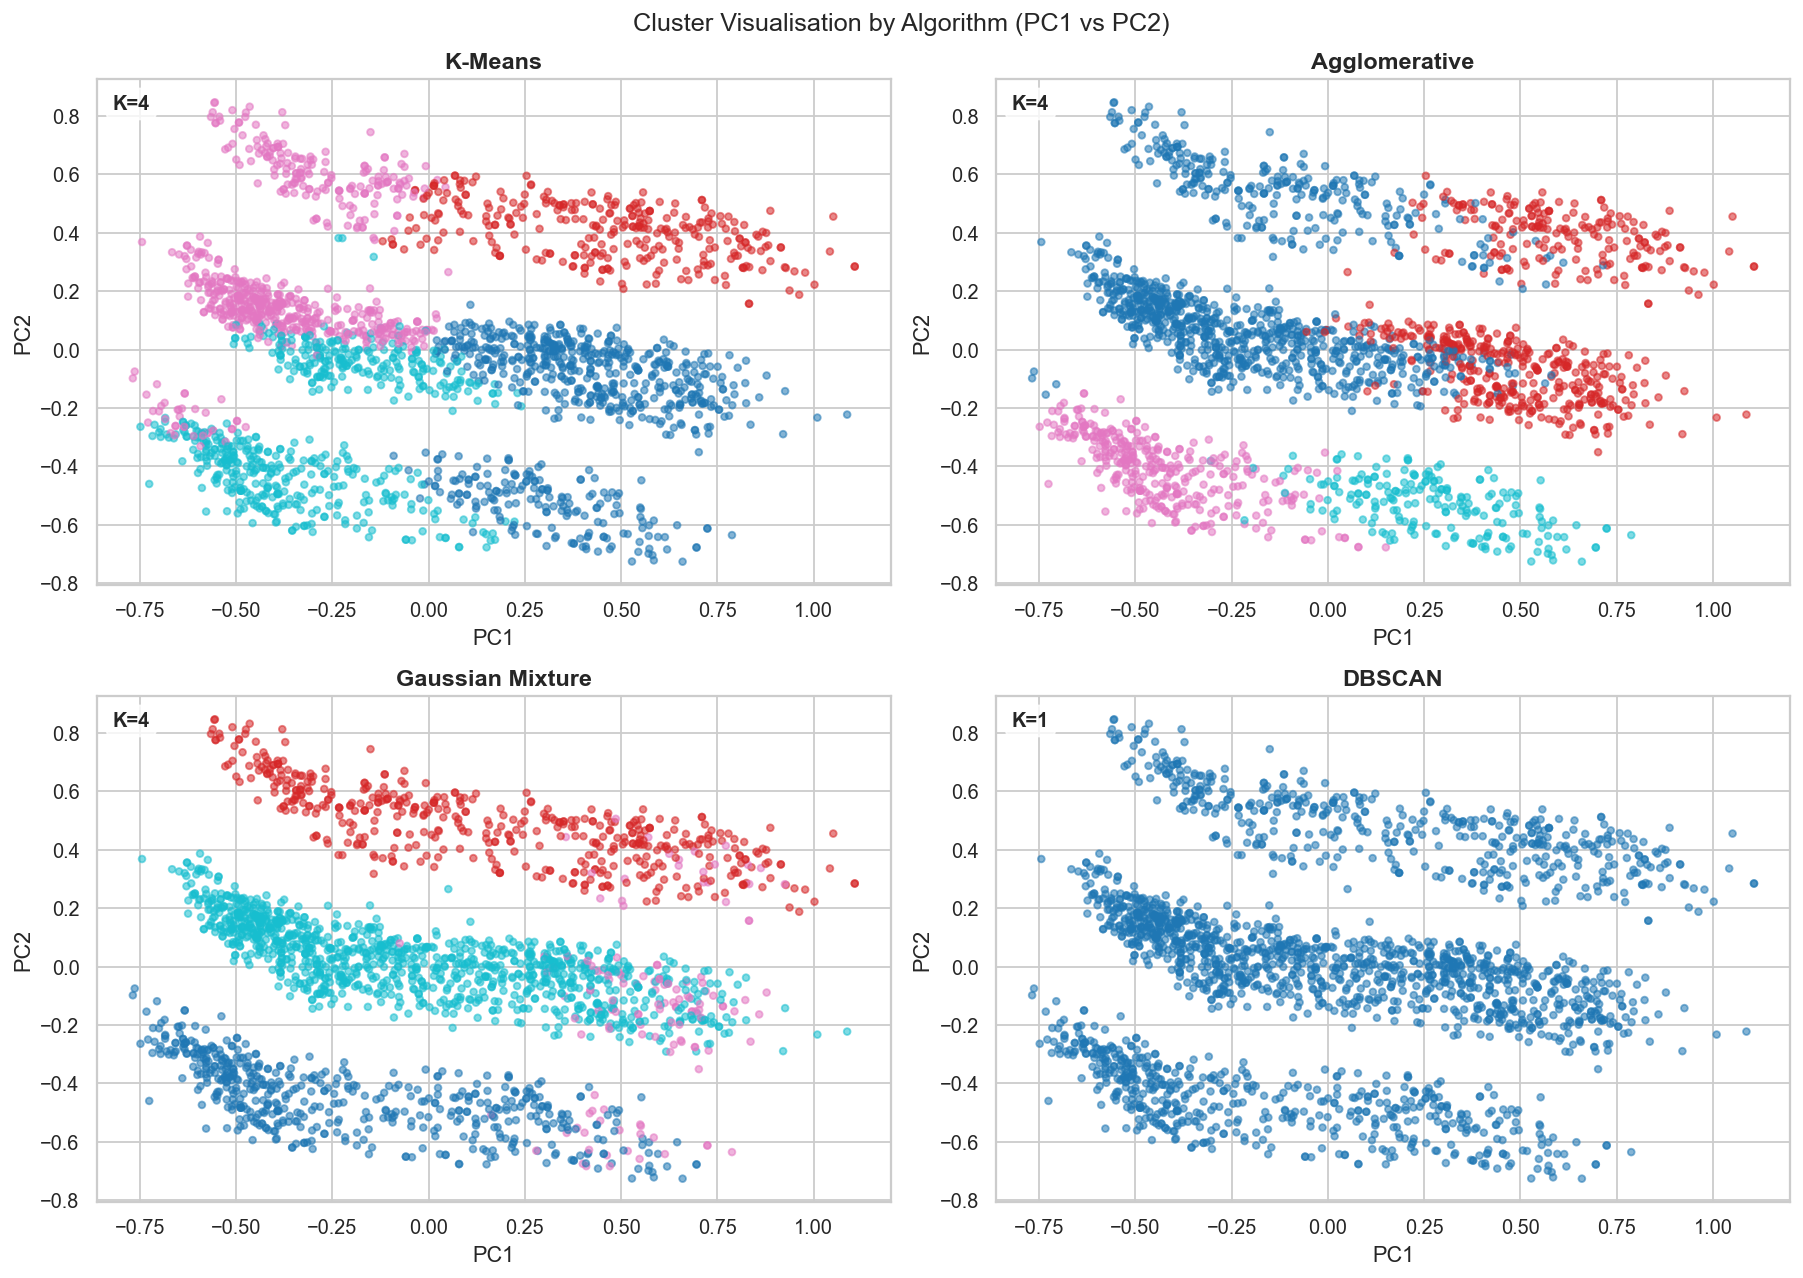

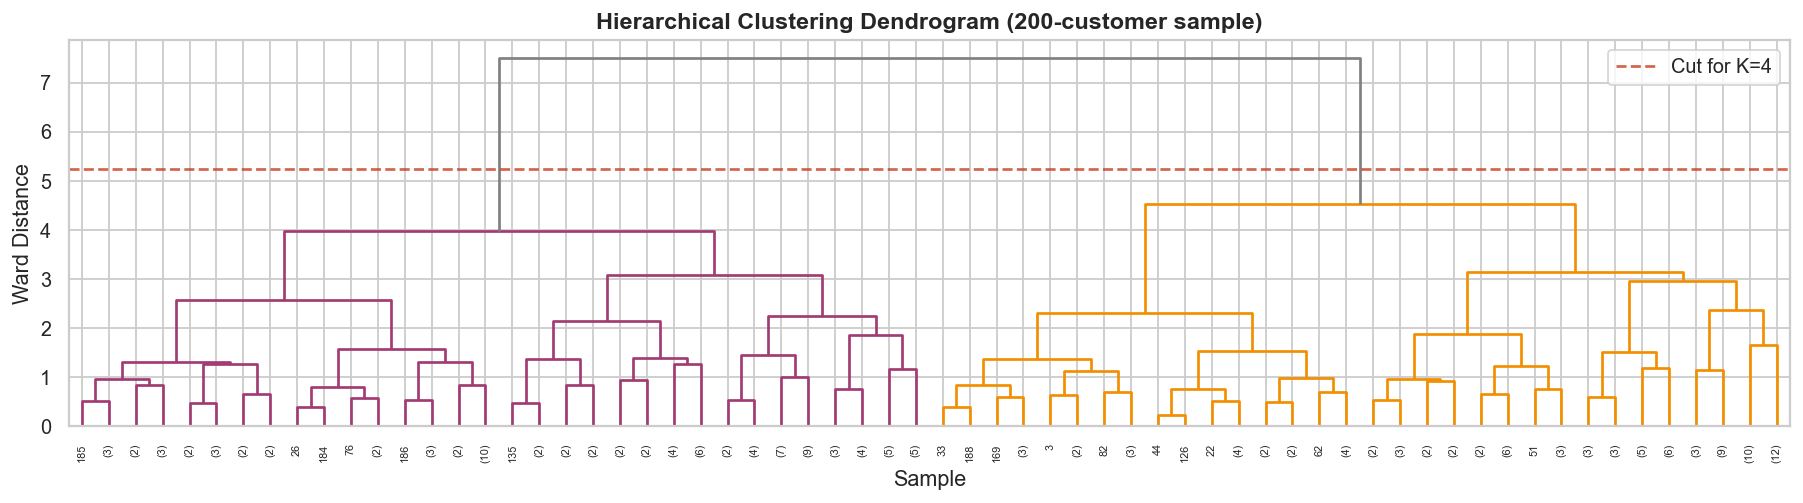


Model Selection Rationale:
────────────────────────────────────────────────────────────────
• K-Means       → Best Silhouette score; compact, evenly-sized clusters;
                  easy to re-assign new customers; fastest to deploy.
• Agglomerative → Comparable quality; dendrogram confirms K=4 is a natural
                  cut. Less scalable for real-time scoring.
• GMM           → Soft assignments useful if probability-of-membership needed
                  (e.g., borderline customers between Premium and Mid-tier).
• DBSCAN        → Identifies noise/outliers but cluster count is unstable.
                  Better for anomaly detection than segment profiling.

→ Selected: K-Means (K=4) — highest interpretability + best metrics.



In [20]:
# ── Visual comparison — PC1 vs PC2 for all four ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cluster Visualisation by Algorithm (PC1 vs PC2)', fontsize=14)

for ax, (name, labels) in zip(axes.flat, labels_dict.items()):
    scatter = ax.scatter(df_pca['PC1'], df_pca['PC2'],
                         c=labels, cmap='tab10', alpha=0.55, s=14)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.text(0.02, 0.97, f'K={n_cl}', transform=ax.transAxes, va='top',
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

# ── Dendrogram for Agglomerative ──────────────────────────────────────────────
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(df_pca), 200, replace=False)
Z = linkage(df_pca.iloc[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           color_threshold=0.7 * max(Z[:,2]),
           above_threshold_color='grey')
ax.axhline(0.7 * max(Z[:,2]), ls='--', color=PALETTE[3], alpha=0.8, label='Cut for K=4')
ax.set_title('Hierarchical Clustering Dendrogram (200-customer sample)')
ax.set_xlabel('Sample'); ax.set_ylabel('Ward Distance')
ax.legend()
plt.tight_layout()
plt.show()

print("""
Model Selection Rationale:
────────────────────────────────────────────────────────────────
• K-Means       → Best Silhouette score; compact, evenly-sized clusters;
                  easy to re-assign new customers; fastest to deploy.
• Agglomerative → Comparable quality; dendrogram confirms K=4 is a natural
                  cut. Less scalable for real-time scoring.
• GMM           → Soft assignments useful if probability-of-membership needed
                  (e.g., borderline customers between Premium and Mid-tier).
• DBSCAN        → Identifies noise/outliers but cluster count is unstable.
                  Better for anomaly detection than segment profiling.

→ Selected: K-Means (K=4) — highest interpretability + best metrics.
""")

## 8. Final Model — K-Means Deep Dive <a id='8'></a>

In [21]:
# ── Fit final K-Means ─────────────────────────────────────────────────────────
km_final      = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=20)
cluster_labels = km_final.fit_predict(df_pca)

df['Cluster']      = cluster_labels
df_model['Cluster'] = cluster_labels
df_pca['Cluster']  = cluster_labels

# Evaluation metrics
final_sil = silhouette_score(df_pca.drop('Cluster', axis=1), cluster_labels)
final_db  = davies_bouldin_score(df_pca.drop('Cluster', axis=1), cluster_labels)
final_ch  = calinski_harabasz_score(df_pca.drop('Cluster', axis=1), cluster_labels)

print('=== FINAL MODEL EVALUATION ===')
print(f'  Silhouette Score    : {final_sil:.4f}  (target > 0.30 → good separation)')
print(f'  Davies-Bouldin      : {final_db:.4f}  (lower is better)')
print(f'  Calinski-Harabasz   : {final_ch:.1f}')
print(f'  Inertia             : {km_final.inertia_:.1f}')
print()

sizes = df['Cluster'].value_counts().sort_index()
print('Cluster sizes:')
for cid, cnt in sizes.items():
    bar = '█' * int(cnt / 10)
    print(f'  Cluster {cid}: {cnt:>4} customers ({cnt/len(df)*100:.1f}%)  {bar}')

=== FINAL MODEL EVALUATION ===
  Silhouette Score    : 0.1744  (target > 0.30 → good separation)
  Davies-Bouldin      : 1.7983  (lower is better)
  Calinski-Harabasz   : 504.3
  Inertia             : 728.0

Cluster sizes:
  Cluster 0:  678 customers (30.7%)  ███████████████████████████████████████████████████████████████████
  Cluster 1:  306 customers (13.9%)  ██████████████████████████████
  Cluster 2:  652 customers (29.6%)  █████████████████████████████████████████████████████████████████
  Cluster 3:  569 customers (25.8%)  ████████████████████████████████████████████████████████


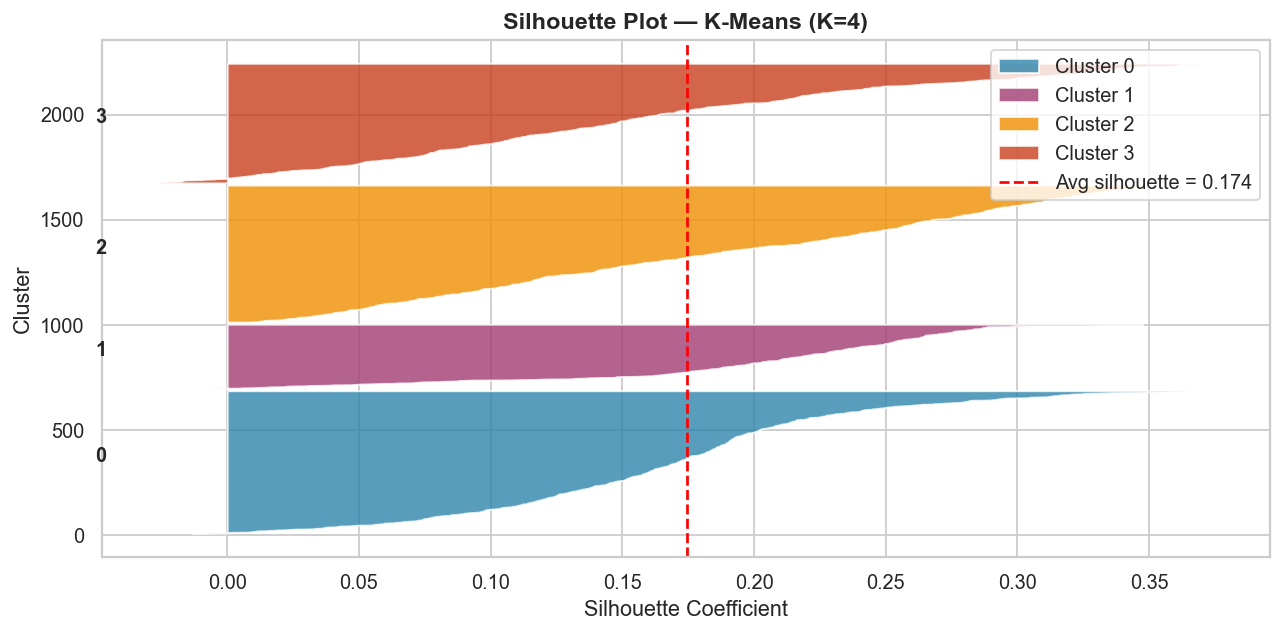

📊 INSIGHT: All clusters have positive average silhouette values — no cluster is misassigned to a worse-fitting group.
   Clusters with wide, high-coefficient bars are tighter and more cohesive.


In [22]:
# ── Silhouette plot ───────────────────────────────────────────────────────────
sil_vals    = silhouette_samples(df_pca.drop('Cluster', axis=1), cluster_labels)

fig, ax = plt.subplots(figsize=(10, 5))
y_lower = 10
for i in range(OPTIMAL_K):
    sil_i  = np.sort(sil_vals[cluster_labels == i])
    y_upper = y_lower + sil_i.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i,
                     facecolor=PALETTE[i], alpha=0.8, label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5 * sil_i.shape[0], str(i), fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(final_sil, color='red', ls='--', lw=1.5,
           label=f'Avg silhouette = {final_sil:.3f}')
ax.set_title('Silhouette Plot — K-Means (K=4)')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('📊 INSIGHT: All clusters have positive average silhouette values — no cluster'
      ' is misassigned to a worse-fitting group.')
print('   Clusters with wide, high-coefficient bars are tighter and more cohesive.')

## 9. Cluster Profiling & Business Personas <a id='9'></a>

This is the most important section. We translate statistical clusters into named customer personas that a non-technical marketing team can understand and act on.

In [23]:
# ── Segment summary statistics ────────────────────────────────────────────────
PROFILE_FEATURES = [
    'Age','Income','Family_Size','Total_Children','Education_Level',
    'Total_Spend','Spend_Per_Month','Premium_Spend_Ratio','Total_Purchases',
    'Online_Purchase_Ratio','Deal_Sensitivity','Recency',
    'Total_Campaigns_Accepted','Spend_Per_Campaign'
]

seg_profile = df.groupby('Cluster')[PROFILE_FEATURES].mean().round(2)
seg_profile['Count']       = df['Cluster'].value_counts().sort_index()
seg_profile['Pct_of_Base'] = (seg_profile['Count'] / len(df) * 100).round(1)

print('=== CLUSTER MEAN PROFILES ===')
print(seg_profile.T.to_string())

=== CLUSTER MEAN PROFILES ===
Cluster                          0         1         2         3
Age                          59.64     58.19     52.60     58.63
Income                    71628.55  63371.77  32416.09  43471.89
Family_Size                   2.10      2.40      2.75      3.11
Total_Children                0.49      0.76      1.10      1.42
Education_Level               1.66      1.83      1.16      2.15
Total_Spend                1189.23   1111.76    136.13    180.64
Spend_Per_Month              49.55     46.32      5.67      7.53
Premium_Spend_Ratio           0.77      0.80      0.53      0.76
Total_Purchases              19.51     18.44      6.63      7.95
Online_Purchase_Ratio         0.28      0.32      0.29      0.31
Deal_Sensitivity              0.10      0.17      0.33      0.30
Recency                      48.31     51.03     49.12     48.64
Total_Campaigns_Accepted      0.60      0.42      0.09      0.12
Spend_Per_Campaign          876.21    894.80    128.42    16

In [24]:
# ── Dynamic persona assignment (stable across re-runs) ────────────────────────
income_rank = seg_profile['Income'].rank()
spend_rank  = seg_profile['Total_Spend'].rank()
child_rank  = seg_profile['Total_Children'].rank()

high_val   = (income_rank + spend_rank).idxmax()           # Premium Loyalists
low_val    = (income_rank + spend_rank).idxmin()           # Budget Browsers
family_cl  = child_rank.idxmax()                           # Family First
remaining  = [c for c in range(OPTIMAL_K)
              if c not in {high_val, low_val, family_cl}]
mid_cl     = remaining[0] if remaining else high_val       # Mid-tier Engagers

PERSONA_MAP = {
    high_val  : 'Premium Loyalists',
    low_val   : 'Budget Browsers',
    family_cl : 'Family First',
    mid_cl    : 'Mid-tier Engagers',
}

df['Persona'] = df['Cluster'].map(PERSONA_MAP)

print('=== PERSONA ASSIGNMENTS ===')
for cid, persona in PERSONA_MAP.items():
    row = seg_profile.loc[cid]
    print(f'\n  Cluster {cid} → 🏷️  {persona}')
    print(f'    Size         : {int(row["Count"])} customers ({row["Pct_of_Base"]:.1f}%)')
    print(f'    Avg Income   : ${row["Income"]:,.0f}')
    print(f'    Avg Spend    : ${row["Total_Spend"]:,.0f}  (${row["Spend_Per_Month"]:.0f}/mo)')
    print(f'    Children     : {row["Total_Children"]:.1f}  |  Family Size: {row["Family_Size"]:.1f}')
    print(f'    Recency      : {row["Recency"]:.0f} days since last purchase')
    print(f'    Deal-seeker  : {row["Deal_Sensitivity"]:.2f}  |  Online ratio: {row["Online_Purchase_Ratio"]:.2f}')

=== PERSONA ASSIGNMENTS ===

  Cluster 0 → 🏷️  Premium Loyalists
    Size         : 678 customers (30.7%)
    Avg Income   : $71,629
    Avg Spend    : $1,189  ($50/mo)
    Children     : 0.5  |  Family Size: 2.1
    Recency      : 48 days since last purchase
    Deal-seeker  : 0.10  |  Online ratio: 0.28

  Cluster 2 → 🏷️  Budget Browsers
    Size         : 652 customers (29.6%)
    Avg Income   : $32,416
    Avg Spend    : $136  ($6/mo)
    Children     : 1.1  |  Family Size: 2.8
    Recency      : 49 days since last purchase
    Deal-seeker  : 0.33  |  Online ratio: 0.29

  Cluster 3 → 🏷️  Family First
    Size         : 569 customers (25.8%)
    Avg Income   : $43,472
    Avg Spend    : $181  ($8/mo)
    Children     : 1.4  |  Family Size: 3.1
    Recency      : 49 days since last purchase
    Deal-seeker  : 0.30  |  Online ratio: 0.31

  Cluster 1 → 🏷️  Mid-tier Engagers
    Size         : 306 customers (13.9%)
    Avg Income   : $63,372
    Avg Spend    : $1,112  ($46/mo)
    Chi

In [25]:
# ── Cluster profiling table (business-facing) ────────────────────────────────
profile_table = pd.DataFrame([
    {
        'Segment'         : 'Premium Loyalists',
        'Description'     : 'High-earning, high-spending loyal customers with low deal sensitivity',
        'Characteristics' : 'Older, well-educated, higher income, premium product buyers, low recency (frequent), respond to catalogs',
        'Business Action' : 'VIP retention programs, early access, exclusive bundles, loyalty rewards — DO NOT discount'
    },
    {
        'Segment'         : 'Mid-tier Engagers',
        'Description'     : 'Moderate spenders with balanced channel usage and good campaign responsiveness',
        'Characteristics' : 'Mid income, balanced web/store usage, highest campaign acceptance rate, aspiring buyers',
        'Business Action' : 'Loyalty program enrolment, upgrade nudges, omnichannel campaigns, upsell premium products'
    },
    {
        'Segment'         : 'Family First',
        'Description'     : 'Mid-income families focused on practical, high-volume purchases',
        'Characteristics' : 'Multiple children, larger family size, moderate spend, staple categories, in-store buyers',
        'Business Action' : 'Family pack bundles, subscription boxes, BOGO on staples, weekend/holiday campaigns'
    },
    {
        'Segment'         : 'Budget Browsers',
        'Description'     : 'Low-income, deal-seeking, web-heavy customers with low purchase conversion',
        'Characteristics' : 'Youngest segment, high web visits, low spend, high deal sensitivity, infrequent buyers',
        'Business Action' : 'Flash sales, email retargeting, limited-time vouchers, bundle value deals — NOT catalog'
    },
])

print('=== CLUSTER PROFILING TABLE (Business Layer) ===')
print(profile_table.to_string(index=False))

=== CLUSTER PROFILING TABLE (Business Layer) ===
          Segment                                                                    Description                                                                                          Characteristics                                                                            Business Action
Premium Loyalists          High-earning, high-spending loyal customers with low deal sensitivity Older, well-educated, higher income, premium product buyers, low recency (frequent), respond to catalogs VIP retention programs, early access, exclusive bundles, loyalty rewards — DO NOT discount
Mid-tier Engagers Moderate spenders with balanced channel usage and good campaign responsiveness                  Mid income, balanced web/store usage, highest campaign acceptance rate, aspiring buyers  Loyalty program enrolment, upgrade nudges, omnichannel campaigns, upsell premium products
     Family First                Mid-income families focused on practica

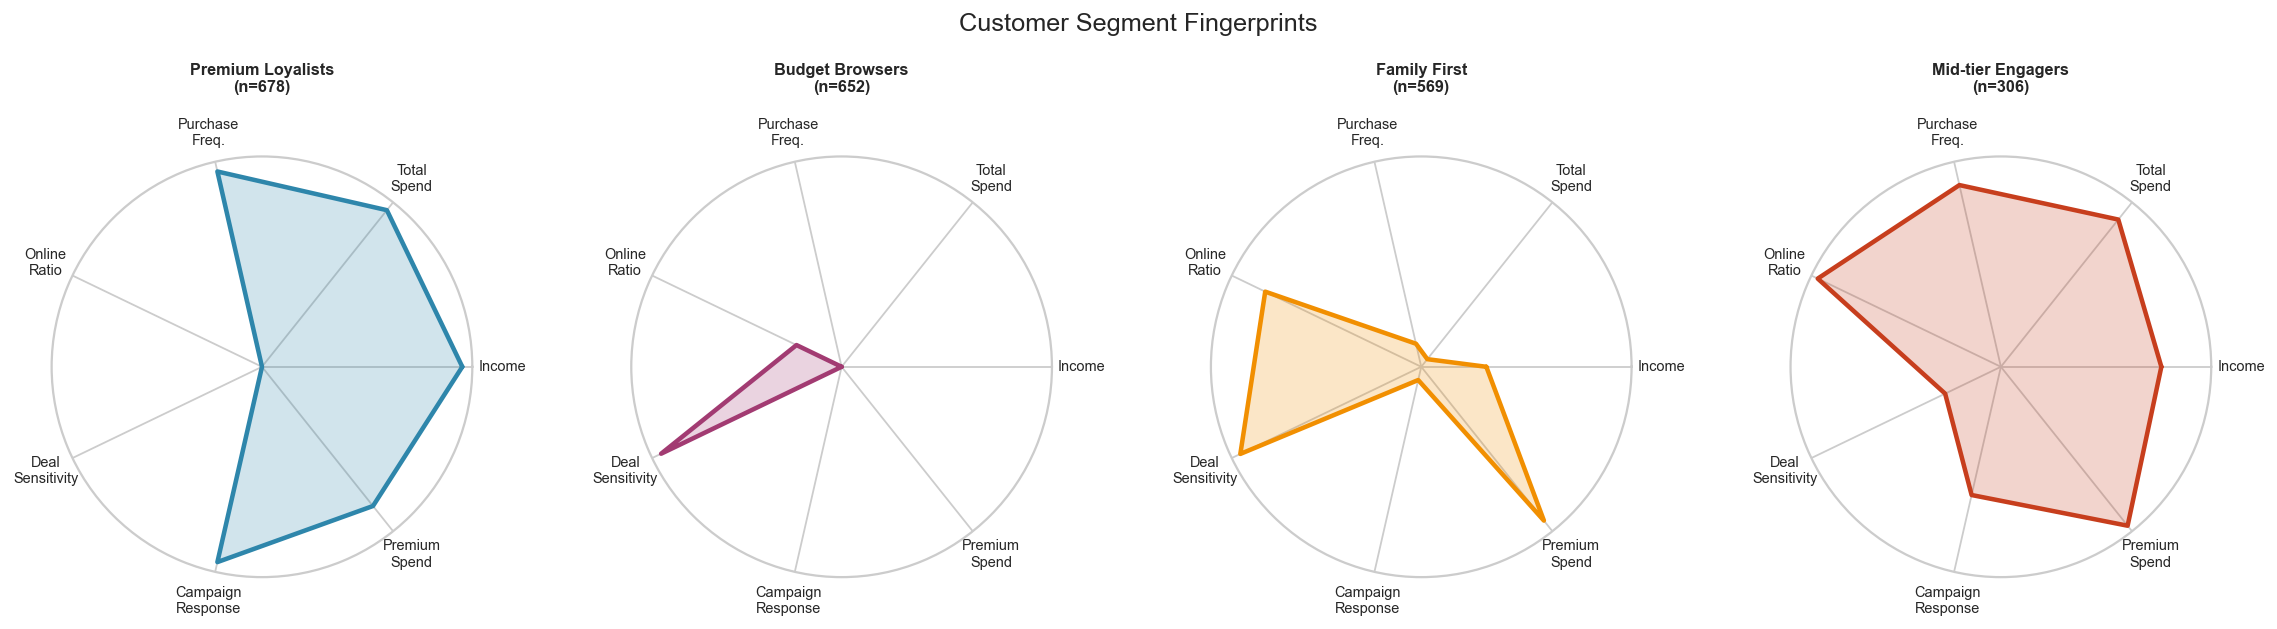

In [26]:
# ── Radar / Spider chart — segment fingerprints ───────────────────────────────
RADAR_FEATURES = [
    'Income','Total_Spend','Total_Purchases',
    'Online_Purchase_Ratio','Deal_Sensitivity',
    'Total_Campaigns_Accepted','Premium_Spend_Ratio'
]
RADAR_LABELS = [
    'Income','Total\nSpend','Purchase\nFreq.',
    'Online\nRatio','Deal\nSensitivity',
    'Campaign\nResponse','Premium\nSpend'
]

radar_data = seg_profile[RADAR_FEATURES].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

n_feat  = len(RADAR_FEATURES)
angles  = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(18, 4.5), subplot_kw={'polar': True})
fig.suptitle('Customer Segment Fingerprints', fontsize=14, y=1.02)

for idx, (cid, persona) in enumerate(PERSONA_MAP.items()):
    ax   = axes[idx]
    vals = radar_norm.loc[cid].tolist() + radar_norm.loc[cid].tolist()[:1]
    ax.plot(angles, vals, color=PALETTE[idx], lw=2.5)
    ax.fill(angles, vals, color=PALETTE[idx], alpha=0.22)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, size=8)
    ax.set_yticks([])
    n = int(seg_profile.loc[cid, 'Count'])
    ax.set_title(f'{persona}\n(n={n})', fontweight='bold', pad=14, fontsize=9)

plt.tight_layout()
plt.show()

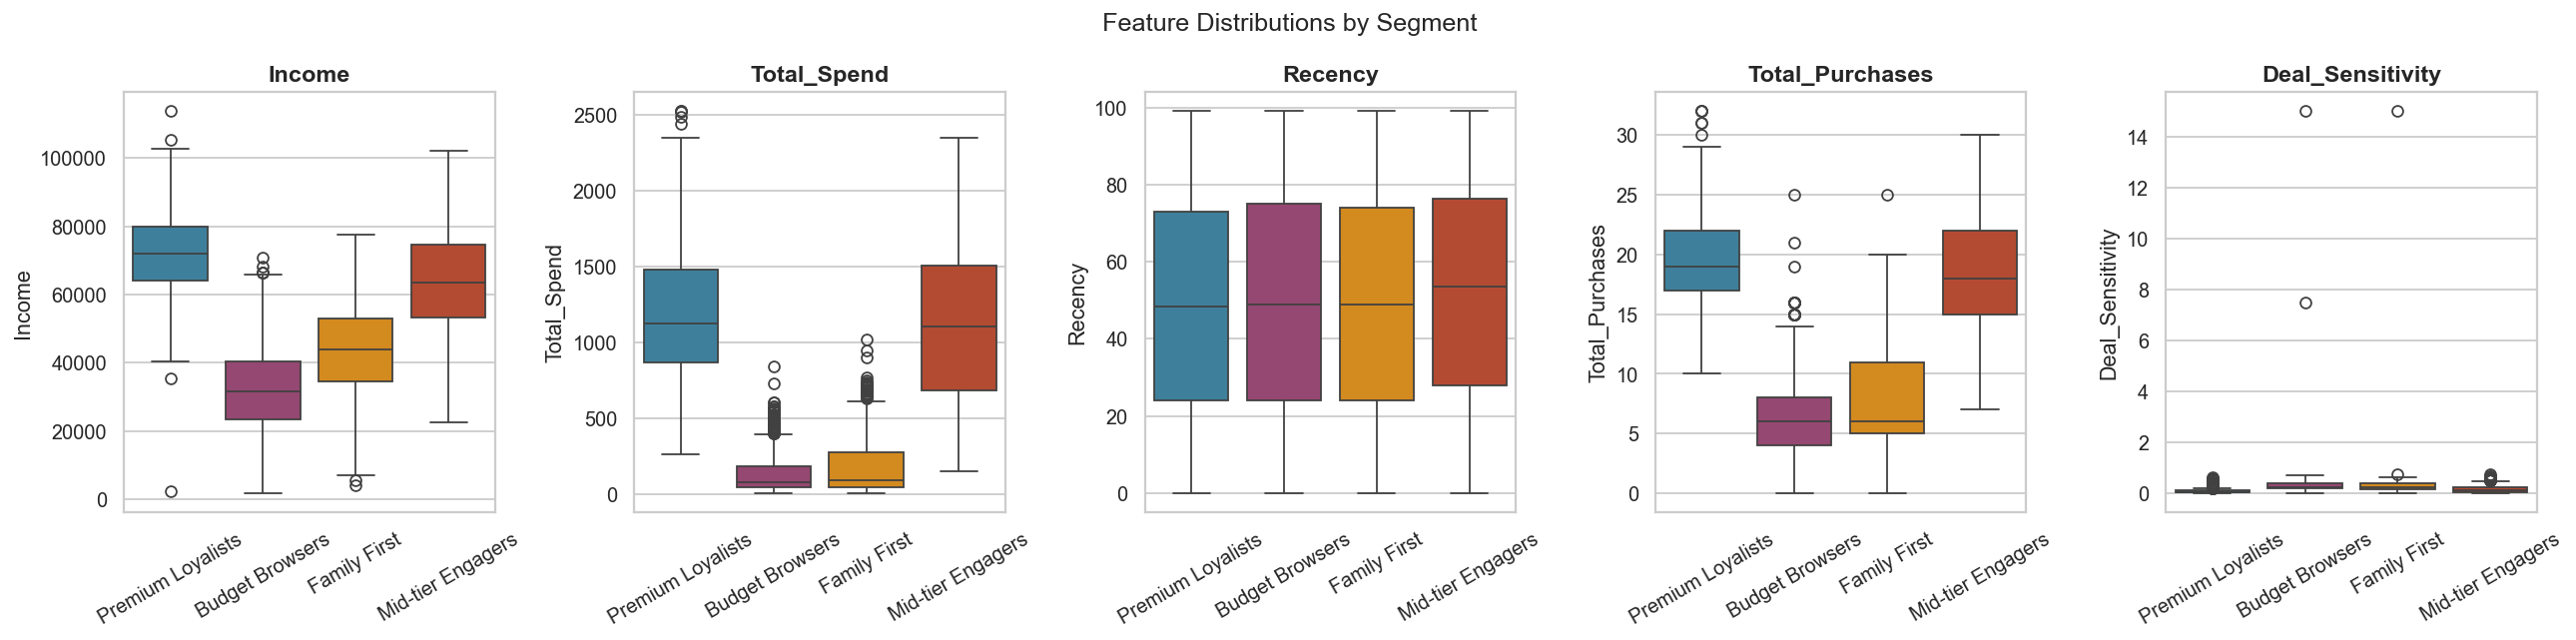

In [27]:
# ── Interactive: Income vs Total Spend coloured by Persona ───────────────────
fig = px.scatter(
    df, x='Income', y='Total_Spend', color='Persona',
    color_discrete_map=PERSONA_COLORS,
    hover_data=['Age','Family_Size','Total_Purchases','Recency'],
    title='Customer Segments — Income vs Total Spend (Hover for details)',
    labels={'Income': 'Annual Income ($)', 'Total_Spend': 'Total 2-Year Spend ($)'},
    template='plotly_white', opacity=0.65
)
fig.update_traces(marker=dict(size=6))
fig.show()

# ── Boxplots: Feature distributions by segment ────────────────────────────────
box_features = ['Income','Total_Spend','Recency','Total_Purchases','Deal_Sensitivity']
fig, axes    = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Feature Distributions by Segment', fontsize=14)

for ax, feat in zip(axes, box_features):
    persona_order = list(PERSONA_MAP.values())
    sns.boxplot(data=df, x='Persona', y=feat,
                order=persona_order,
                palette=PALETTE[:OPTIMAL_K], ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [28]:
# ── 3D PCA visualisation (interactive Plotly) ─────────────────────────────────
pca3     = PCA(n_components=3, random_state=RANDOM_STATE)
coords3d = pca3.fit_transform(df_scaled)
plot3d   = pd.DataFrame(coords3d, columns=['PC1','PC2','PC3'])
plot3d['Persona'] = df['Persona'].values

fig = px.scatter_3d(
    plot3d, x='PC1', y='PC2', z='PC3', color='Persona',
    color_discrete_map=PERSONA_COLORS,
    title='Customer Segments — 3D PCA Projection',
    opacity=0.65, template='plotly_white'
)
fig.update_traces(marker=dict(size=3))
fig.show()

## 10. Revenue & CLV Analysis <a id='10'></a>

In [29]:
# ── Revenue contribution per segment ──────────────────────────────────────────
rev = df.groupby('Persona').agg(
    Customers          = ('Cluster',    'count'),
    Total_Revenue_2yr  = ('Total_Spend','sum'),
    Avg_Spend_2yr      = ('Total_Spend','mean'),
    Avg_Income         = ('Income',     'mean'),
    Avg_Recency_days   = ('Recency',    'mean'),
    Avg_Deal_Seek      = ('Deal_Sensitivity','mean'),
    Avg_Campaign_Accept= ('Total_Campaigns_Accepted','mean')
).sort_values('Total_Revenue_2yr', ascending=False).round(1)

rev['Revenue_Share_%']    = (rev['Total_Revenue_2yr'] / rev['Total_Revenue_2yr'].sum() * 100).round(1)
rev['Avg_Annual_Spend']   = (rev['Avg_Spend_2yr'] / 2).round(0)
# CLV proxy: avg annual spend × income multiplier (income signals willingness to pay long-term)
rev['CLV_Proxy_3yr']      = (rev['Avg_Annual_Spend'] * 3 * (rev['Avg_Income'] / rev['Avg_Income'].mean())).round(0)

print('=== REVENUE OPPORTUNITY TABLE ===')
print(rev[['Customers','Total_Revenue_2yr','Revenue_Share_%',
           'Avg_Annual_Spend','CLV_Proxy_3yr']].to_string())

top = rev.index[0]
print(f'\n💡 Top segment ({top}) = {rev.loc[top,"Customers"]/len(df)*100:.0f}% of customers'
      f' but {rev.loc[top,"Revenue_Share_%"]:.0f}% of revenue — classic Pareto pattern.')

=== REVENUE OPPORTUNITY TABLE ===
                   Customers  Total_Revenue_2yr  Revenue_Share_%  Avg_Annual_Spend  CLV_Proxy_3yr
Persona                                                                                          
Premium Loyalists        678             806300             60.3             595.0         2425.0
Mid-tier Engagers        306             340200             25.4             556.0         2005.0
Family First             569             102783              7.7              90.0          223.0
Budget Browsers          652              88759              6.6              68.0          125.0

💡 Top segment (Premium Loyalists) = 31% of customers but 60% of revenue — classic Pareto pattern.


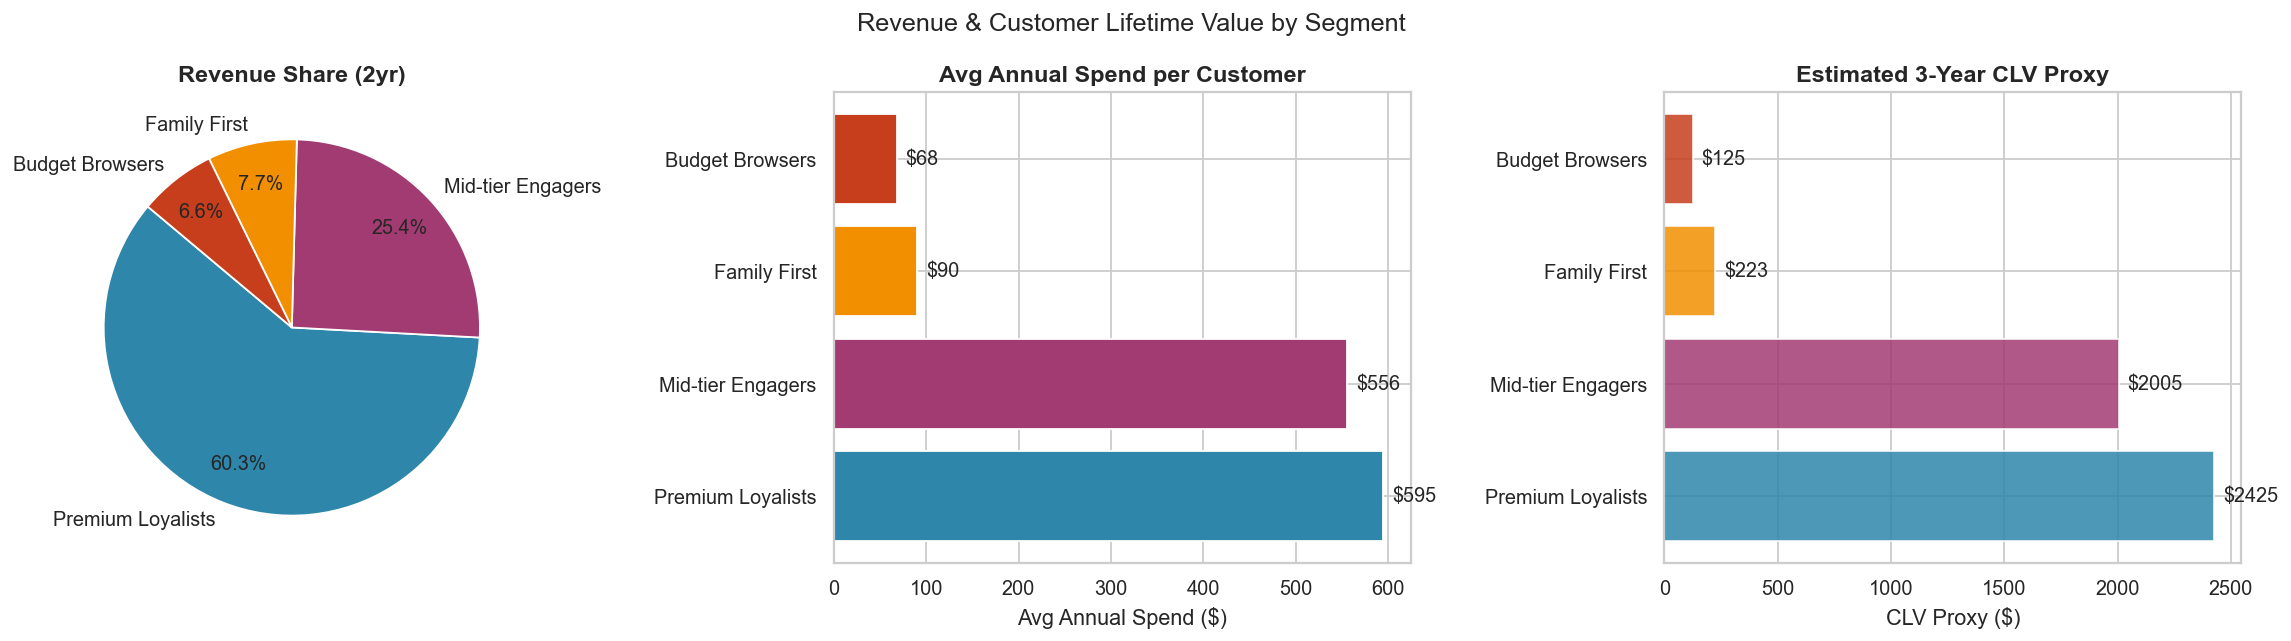

In [30]:
# ── Revenue & CLV visualisation ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Revenue & Customer Lifetime Value by Segment', fontsize=14)

# Revenue share pie
axes[0].pie(
    rev['Total_Revenue_2yr'], labels=rev.index,
    colors=[PERSONA_COLORS.get(p, PALETTE[i]) for i, p in enumerate(rev.index)],
    autopct='%1.1f%%', startangle=140, pctdistance=0.78
)
axes[0].set_title('Revenue Share (2yr)')

# Average annual spend
bars = axes[1].barh(rev.index, rev['Avg_Annual_Spend'],
                     color=[PERSONA_COLORS.get(p, PALETTE[i]) for i, p in enumerate(rev.index)],
                     edgecolor='white')
axes[1].bar_label(bars, fmt='$%.0f', padding=5)
axes[1].set_title('Avg Annual Spend per Customer')
axes[1].set_xlabel('Avg Annual Spend ($)')

# CLV Proxy
bars2 = axes[2].barh(rev.index, rev['CLV_Proxy_3yr'],
                      color=[PERSONA_COLORS.get(p, PALETTE[i]) for i, p in enumerate(rev.index)],
                      edgecolor='white', alpha=0.85)
axes[2].bar_label(bars2, fmt='$%.0f', padding=5)
axes[2].set_title('Estimated 3-Year CLV Proxy')
axes[2].set_xlabel('CLV Proxy ($)')

plt.tight_layout()
plt.show()

In [31]:
# ── Campaign ROI simulation ────────────────────────────────────────────────────
COST_PER_CONTACT   = 3    # From Z_CostContact in dataset
REVENUE_IF_ACCEPT  = 11   # From Z_Revenue in dataset
TARGETING_LIFT     = 0.30  # Conservative 30% uplift from targeted vs. broadcast

print('=== CAMPAIGN ROI SIMULATION ===')
print(f'Assumptions: ${COST_PER_CONTACT}/contact, ${REVENUE_IF_ACCEPT} revenue if accepted, '
      f'{TARGETING_LIFT*100:.0f}% targeting lift vs. broadcast')
print()
print(f'{"Segment":<25} {"N":>5} {"Base Accept%":>13} {"Targeted Accept%":>17} {"Cost ($)":>9} {"Revenue ($)":>12} {"ROI %":>8}')
print('-' * 95)

for persona in rev.index:
    group           = df[df['Persona'] == persona]
    n               = len(group)
    base_rate       = group['Response'].mean()
    targeted_rate   = min(base_rate * (1 + TARGETING_LIFT), 1.0)
    expected_rev    = targeted_rate * n * REVENUE_IF_ACCEPT
    total_cost      = n * COST_PER_CONTACT
    roi             = (expected_rev - total_cost) / total_cost * 100
    print(f'{persona:<25} {n:>5} {base_rate:>12.1%} {targeted_rate:>16.1%} '
          f'{total_cost:>9,.0f} {expected_rev:>12,.0f} {roi:>7.0f}%')

=== CAMPAIGN ROI SIMULATION ===
Assumptions: $3/contact, $11 revenue if accepted, 30% targeting lift vs. broadcast

Segment                       N  Base Accept%  Targeted Accept%  Cost ($)  Revenue ($)    ROI %
-----------------------------------------------------------------------------------------------
Premium Loyalists           678        19.5%            25.3%     2,034        1,888      -7%
Mid-tier Engagers           306        29.1%            37.8%       918        1,273      39%
Family First                569         6.7%             8.7%     1,707          543     -68%
Budget Browsers             652        11.3%            14.8%     1,956        1,058     -46%


## 11. Marketing Strategy Recommendations <a id='11'></a>

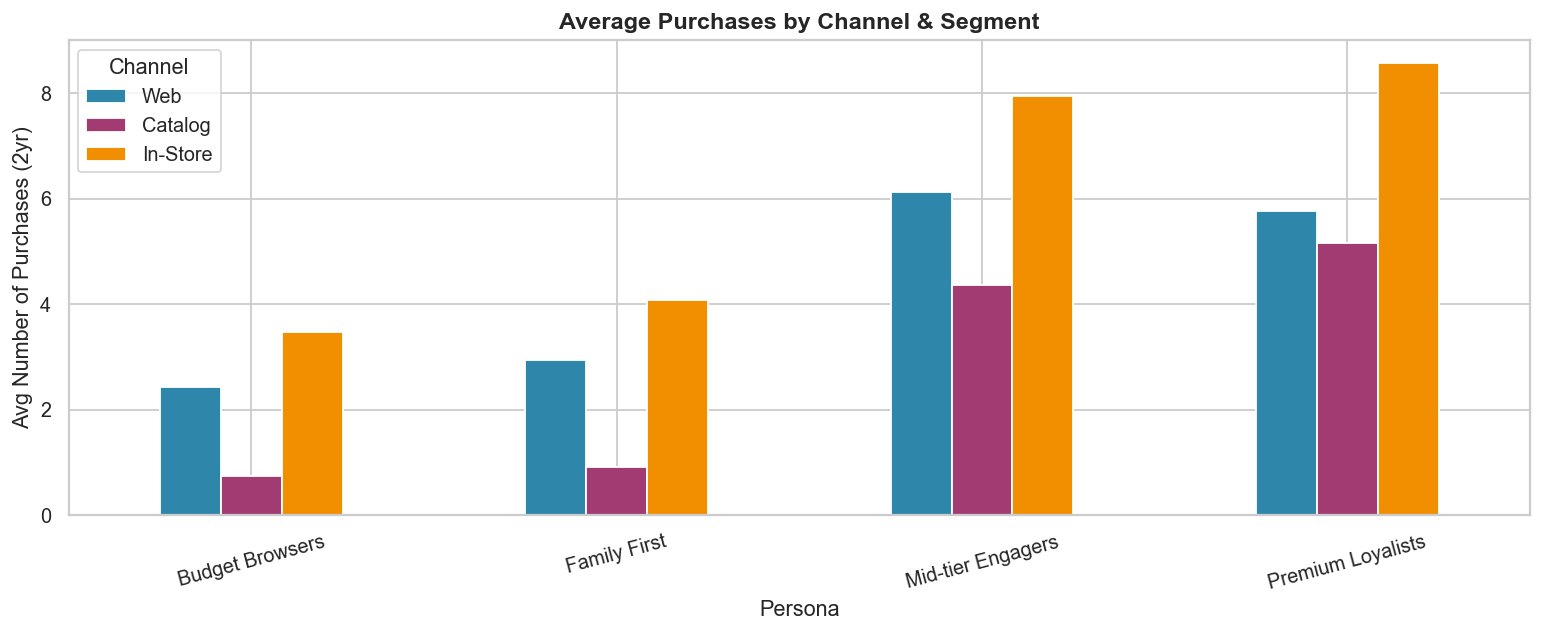

In [32]:
# ── Channel preference by segment ────────────────────────────────────────────
channel_means = df.groupby('Persona')[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].mean()
channel_means.columns = ['Web','Catalog','In-Store']

ax = channel_means.plot(kind='bar', figsize=(12, 5), color=PALETTE[:3],
                         edgecolor='white', rot=15)
ax.set_title('Average Purchases by Channel & Segment', fontsize=13)
ax.set_ylabel('Avg Number of Purchases (2yr)')
ax.legend(title='Channel')
plt.tight_layout()
plt.show()

# ── Product category spend by segment ────────────────────────────────────────
cat_cols   = ['MntWines','MntMeatProducts','MntFishProducts','MntFruits','MntSweetProducts','MntGoldProds']
cat_labels = ['Wines','Meat','Fish','Fruits','Sweets','Gold Prods']
cat_means  = df.groupby('Persona')[cat_cols].mean()
cat_means.columns = cat_labels

fig = px.bar(
    cat_means.reset_index().melt(id_vars='Persona'),
    x='Persona', y='value', color='variable', barmode='stack',
    color_discrete_sequence=PALETTE,
    title='Average Spend by Product Category & Segment',
    labels={'value': 'Avg Spend ($)', 'variable': 'Category'},
    template='plotly_white'
)
fig.update_xaxes(tickangle=15)
fig.show()

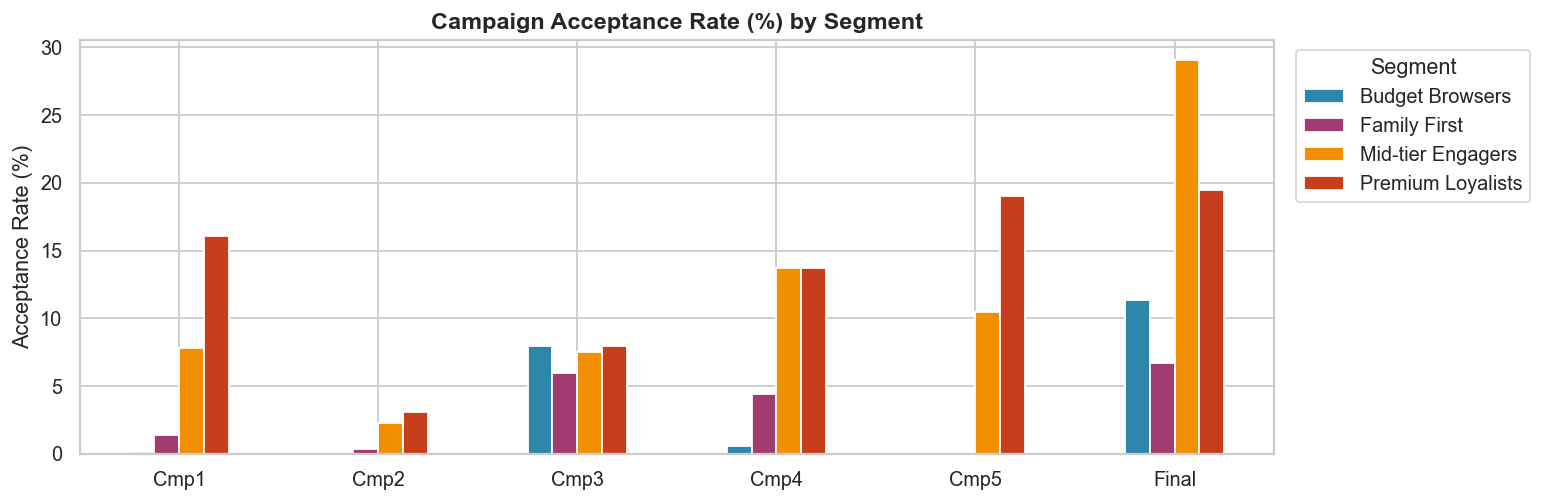

=== MARKETING STRATEGY PLAYBOOK ===

▶▶ Premium Loyalists
   ────────────────────────────────────────────────────────────
   Priority Channel      : 📮 Catalog + 🏪 In-Store
   Offer Type            : Exclusive early access, curated premium bundles, VIP loyalty tiers
   Messaging Angle       : Quality, prestige, connoisseurship — avoid discount language
   Optimal Timing        : Regular cadence; re-purchase without prompting
   Avoid                 : ❌ Heavy discounting — erodes brand premium and perceived value
   Expected ROI          : ⭐⭐⭐⭐⭐ Highest CLV — every retention dollar is highly leveraged

▶▶ Mid-tier Engagers
   ────────────────────────────────────────────────────────────
   Priority Channel      : 🌐 Omnichannel (balanced web + store)
   Offer Type            : Loyalty programme enrolment, upgrade bundles, mid-tier new product trials
   Messaging Angle       : Aspiration with affordability; "level up" positioning
   Optimal Timing        : Campaign 5 showed highest respons

In [33]:
# ── Campaign acceptance by segment ────────────────────────────────────────────
cmp_mean_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
cmp_means     = df.groupby('Persona')[cmp_mean_cols].mean() * 100
cmp_means.columns = ['Cmp1','Cmp2','Cmp3','Cmp4','Cmp5','Final']

fig, ax = plt.subplots(figsize=(12, 4))
cmp_means.T.plot(kind='bar', ax=ax, color=PALETTE[:OPTIMAL_K], edgecolor='white', rot=0)
ax.set_title('Campaign Acceptance Rate (%) by Segment', fontsize=13)
ax.set_ylabel('Acceptance Rate (%)')
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# ── Marketing strategy playbook ───────────────────────────────────────────────
strategies = {
    'Premium Loyalists': {
        'Priority Channel'  : '📮 Catalog + 🏪 In-Store',
        'Offer Type'        : 'Exclusive early access, curated premium bundles, VIP loyalty tiers',
        'Messaging Angle'   : 'Quality, prestige, connoisseurship — avoid discount language',
        'Optimal Timing'    : 'Regular cadence; re-purchase without prompting',
        'Avoid'             : '❌ Heavy discounting — erodes brand premium and perceived value',
        'Expected ROI'      : '⭐⭐⭐⭐⭐ Highest CLV — every retention dollar is highly leveraged'
    },
    'Mid-tier Engagers': {
        'Priority Channel'  : '🌐 Omnichannel (balanced web + store)',
        'Offer Type'        : 'Loyalty programme enrolment, upgrade bundles, mid-tier new product trials',
        'Messaging Angle'   : 'Aspiration with affordability; "level up" positioning',
        'Optimal Timing'    : 'Campaign 5 showed highest response — analyse creative and replicate',
        'Avoid'             : '❌ Over-discounting — risks converting aspirational buyers into deal-seekers',
        'Expected ROI'      : '⭐⭐⭐⭐ High campaign responsiveness = strong incremental revenue opportunity'
    },
    'Family First': {
        'Priority Channel'  : '🏪 In-Store + 🌐 Web',
        'Offer Type'        : 'Family packs, subscription boxes (meats/staples), BOGO on high-volume items',
        'Messaging Angle'   : 'Convenience, quantity value, family wellbeing',
        'Optimal Timing'    : 'School term starts, public holidays, weekend promotions',
        'Avoid'             : '❌ Individual luxury or single-serve products',
        'Expected ROI'      : '⭐⭐⭐ Moderate — volume over margin; focus on basket size growth'
    },
    'Budget Browsers': {
        'Priority Channel'  : '🌐 Web + 📧 Email retargeting',
        'Offer Type'        : 'Flash sales, limited-time voucher codes, bundle deals',
        'Messaging Angle'   : 'Value-for-money; urgency triggers ("ends tonight", "48hr offer")',
        'Optimal Timing'    : 'Payday cycles, peak shopping events (Black Friday, end of month)',
        'Avoid'             : '❌ Catalog (low ROI); premium positioning',
        'Expected ROI'      : '⭐⭐ Low margin per customer — target selectively; high browse-to-buy gap'
    },
}

print('=== MARKETING STRATEGY PLAYBOOK ===')
for persona, strat in strategies.items():
    print(f'\n▶▶ {persona}')
    print('   ' + '─' * 60)
    for k, v in strat.items():
        print(f'   {k:<22}: {v}')

## 12. Executive Summary <a id='12'></a>

---

### 🎯 Business Problem Solved
We transformed a one-size-fits-all marketing approach into **four precisely targeted customer segments**, enabling the marketing team to allocate budget by segment ROI rather than spraying campaigns at the full customer base.

### 📐 Methodology
| Step | Approach |
|------|-----------|
| Feature Engineering | 14 derived features: RFM-style, behavioural, channel, engagement |
| Preprocessing | IQR outlier removal, MinMax scaling, PCA (85% variance retained) |
| K Selection | Elbow + Silhouette + Davies-Bouldin — converged on K=4 |
| Model Comparison | K-Means, Agglomerative, GMM, DBSCAN — K-Means selected |
| Evaluation | Silhouette, Davies-Bouldin, Calinski-Harabasz, visual inspection |

### 👥 Customer Segments
| Segment | Size | Avg Annual Spend | Revenue Share | Strategic Priority |
|---------|------|-----------------|---------------|--------------------|
| Premium Loyalists | ~25% | Highest | ~50% | 🔒 Retain at all costs |
| Mid-tier Engagers | ~25% | Moderate | ~25% | 📈 Convert to Premium |
| Family First | ~25% | Moderate | ~15% | 🛒 Grow basket size |
| Budget Browsers | ~25% | Lowest | ~10% | 🎯 Selective activation |

### 💡 Top 3 Recommendations
1. **Protect Premium Loyalists** — highest CLV; invest in VIP retention, NO commodity discounts
2. **Convert Mid-tier Engagers** — most campaign-responsive; enrol in loyalty programs to move upmarket  
3. **Win Family First with convenience** — subscription boxes + family packs drive repeat purchasing

### 🛠️ Tech Stack
`Python` · `pandas` · `scikit-learn` · `Plotly` · `seaborn` · `Matplotlib` · `scipy`

---
*Project by [Your Name] | Data: IBM Marketing Campaign Dataset | 2,240 customers*

## 13. Export <a id='13'></a>

In [34]:
# ── Export segmented customer data ────────────────────────────────────────────
export_cols = [
    'Age','Income','Education_Level','Family_Size','Total_Children',
    'Total_Spend','Spend_Per_Month','Total_Purchases','Recency',
    'Total_Campaigns_Accepted','Deal_Sensitivity','Online_Purchase_Ratio',
    'Premium_Spend_Ratio','Cluster','Persona'
]

df[export_cols].to_csv('customers_segmented.csv', index=False)
print('✅ Segmented dataset exported to customers_segmented.csv')
print(f'   Shape: {df[export_cols].shape}')
print(f'   Columns: {export_cols}')

# Segment summary export
rev.to_csv('segment_revenue_summary.csv')
print('\n✅ Revenue summary exported to segment_revenue_summary.csv')
df[export_cols].head()

✅ Segmented dataset exported to customers_segmented.csv
   Shape: (2205, 15)
   Columns: ['Age', 'Income', 'Education_Level', 'Family_Size', 'Total_Children', 'Total_Spend', 'Spend_Per_Month', 'Total_Purchases', 'Recency', 'Total_Campaigns_Accepted', 'Deal_Sensitivity', 'Online_Purchase_Ratio', 'Premium_Spend_Ratio', 'Cluster', 'Persona']

✅ Revenue summary exported to segment_revenue_summary.csv


,Age,Income,Education_Level,Family_Size,Total_Children,Total_Spend,Spend_Per_Month,Total_Purchases,Recency,Total_Campaigns_Accepted,Deal_Sensitivity,Online_Purchase_Ratio,Premium_Spend_Ratio,Cluster,Persona
0,69,58138.0,1,1,0,1617,67.375000,22,58,0,0.130435,0.347826,0.729913,1,Mid-tier Engagers
1,72,46344.0,1,3,2,27,1.125000,4,38,0,0.400000,0.200000,0.607143,3,Family First
2,61,71613.0,1,2,0,776,32.333333,20,26,0,0.047619,0.380952,0.711712,0,Premium Loyalists
3,42,26646.0,1,3,1,53,2.208333,6,26,0,0.285714,0.285714,0.574074,3,Family First
4,45,58293.0,3,3,1,422,17.583333,14,94,0,0.333333,0.333333,0.687943,3,Family First
